### IMPORT AND DEPENDENCIES

In [1]:
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
import pandas as pd
import multiprocessing
import time
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import math
import seaborn as sns

### FUNCTION

In [17]:
def find_terms_vectors(terms_list, model, vocabulary, max_words=5):
    '''
    :param terms_list: a list of relevant terms embeddings of which 
                       should be found in the model.
    :param model: a Doc2Vec or Word2Vec gensim model.
    :param vocabulary: vocabulary of the model.
    :param max_words: maximum number of words per term (default: 5).
    :return: a list of terms found in the vocabulary and a list of 
             corresponding vectors.
    '''
    wv = []
    terms = []
    
    for term in terms_list:
        words = term.split()
        
        # Check: term has between 1 and max_words words,
        # and ALL words are in the vocabulary
        if 1 <= len(words) <= max_words and \
           all(word in vocabulary for word in words):
            
            # Sum vectors of all words in the term
            vector = model.wv[words[0]]
            for word in words[1:]:
                vector = vector + model.wv[word]
            
            wv.append(vector)
            terms.append(term)
    
    return terms, wv

### CONFIGURATION

In [6]:

DATA_PATH  = "./../data/all_bundestag_speeches_preprocessed.csv"
TEXT_COL      = "text_preprocessed_lemmatized"  
FALLBACK_COL  = "text_preprocessed"             
PARTY_COL     = "Party"
SEP           = ";"   
df = pd.read_csv("./results/immigration_speeches_short.csv")                        
len(df)

28662

### ROLLING-WINDOW DOC2VEC TRAINING AND SIMILARITY CALCULATION

In [ ]:

cores = multiprocessing.cpu_count()

data = df
data.index = pd.PeriodIndex(data.date, freq='Q')

# Create a list of periods and sub-periods for the analysis
periods = pd.PeriodIndex(pd.date_range('1960-01-01', periods=262, freq='Q'))
subperiods = []
forecast_periods = []
for i in range(80, 222, 1):
    subperiods.append(periods[i:i + 40])
    forecast_periods.append(periods[i + 40])

# Add columns for similarity metrics to the data frame
data['similarity_expansive'] = np.nan
data['similarity_restrictive'] = np.nan

# Set parameters for the Doc2Vec model
set_window = 5
set_epochs = 50
set_vector_size = 100
dictionary = 'extended'

# Define the directory to save the trained models
models_directory = Path(f"results/doc2vec_models2/{set_window}Window_{set_epochs}Epochs_{set_vector_size}Size")
models_directory.mkdir(parents=True, exist_ok=True)

# Load migration policy terms
expansive = pd.read_csv('./results/new_welcoming_words.csv')['welcoming_terms'].values
restrictive = pd.read_csv('./results/new_restrictive_words.csv')['restrictive_terms'].values


# Track the total start time
starttime = time.time()

# Loop through each subperiod
for i, period in enumerate(subperiods):

    model_path = models_directory / f"doc2vec_subset_{period[0]}_{period[-1]}"

    # --------------------------------------------------
    # Train if model does not exist
    # --------------------------------------------------
    if not model_path.exists():

        print(f"Train model for the period {period[0]}-{period[-1]}.")
        start = time.time()

        # Select subset
        subset = data[data.index.isin(list(period))].reset_index(drop=True)

        # Prepare documents
        sentences = subset.text_preprocessed_lemmatized
        sentences = [s.split() for s in sentences]

        documents = [
            TaggedDocument(doc, [id_])
            for id_, doc in enumerate(sentences)
        ]

        # Train model
        model = Doc2Vec(
            documents,
            dm=0,             
            dbow_words=1,
            workers=cores - 1,
            alpha=0.025,
            vector_size=set_vector_size,
            min_count=1,
            epochs=set_epochs,
            window=set_window,
        )

        print(f"The estimation took {time.time() - start:.2f} seconds.")

        # Save model
        model.save(str(model_path))

    
    # Load existing model
    
    else:

        print(
            f"Loading existing model for period {period[0]}-{period[-1]}"
        )

        model = Doc2Vec.load(str(model_path))


    print(
        f"Calculate similarities to migration policy vectors for period {forecast_periods[i]}"
    )

    # Calculate "welcoming" and "restrictive" vectors for the current period
    vocabulary = [word for index, word in enumerate(model.wv.index_to_key)]
    expansive_terms, expansive_wv = find_terms_vectors(expansive, model, vocabulary)
    restrictive_terms, restrictive_wv = find_terms_vectors(restrictive, model, vocabulary)
    vector_expansive = sum(expansive_wv) / len(expansive_wv) 
    #vector_expansive = model.infer_vector(expansive_terms)
    vector_restrictive = sum(restrictive_wv) / len(restrictive_wv)
    #vector_restrictive =  model.infer_vector(restrictive_terms)

    # Forecast for the next quarter
    forecast_df = data[data.index == forecast_periods[i]]
    document_vectors = [model.infer_vector(text.split()) for text in forecast_df.text_preprocessed_lemmatized]

    # Calculate similarities and store them in the DataFrame
    data.loc[forecast_periods[i], 'similarity_expansive'] = [cosine_similarity([vec], [vector_expansive])[0][0] for vec
                                                             in document_vectors]
    data.loc[forecast_periods[i], 'similarity_restrictive'] = [cosine_similarity([vec], [vector_restrictive])[0][0] for
                                                               vec in document_vectors]

# Track the total end time
endtime = time.time()
print(f'Overall the process took {(endtime - starttime) / 60} minutes.')

# Save the DataFrame to a CSV file
data.to_csv(f'results/doc2vec_10Years_RollingWindow.csv', index=False)

/tmp/ipykernel_1250862/1956607469.py:7: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  periods = pd.PeriodIndex(pd.date_range('1960-01-01', periods=262, freq='Q'))


Loading existing model for period 1980Q1-1989Q4
Calculate similarities to migration policy vectors for period 1990Q1
Loading existing model for period 1980Q2-1990Q1
Calculate similarities to migration policy vectors for period 1990Q2
Loading existing model for period 1980Q3-1990Q2
Calculate similarities to migration policy vectors for period 1990Q3
Loading existing model for period 1980Q4-1990Q3
Calculate similarities to migration policy vectors for period 1990Q4
Loading existing model for period 1981Q1-1990Q4
Calculate similarities to migration policy vectors for period 1991Q1
Loading existing model for period 1981Q2-1991Q1
Calculate similarities to migration policy vectors for period 1991Q2
Loading existing model for period 1981Q3-1991Q2
Calculate similarities to migration policy vectors for period 1991Q3
Loading existing model for period 1981Q4-1991Q3
Calculate similarities to migration policy vectors for period 1991Q4
Loading existing model for period 1982Q1-1991Q4
Calculate simila

### MONTHLY IMMIGRATION SENTIMENT AGGREGATION , LINEAR INTERPOLATION

In [3]:
import pandas as pd

# Read data
data = pd.read_csv(
    "results/doc2vec_10Years_RollingWindow.csv",
    low_memory=False
)



# ----------------------------------------------------------
# Convert date to datetime
# ----------------------------------------------------------
data["date"] = pd.to_datetime(data["date"])

# ----------------------------------------------------------
# Compute sentiment
# ----------------------------------------------------------
data["sentiment"] = (
    pd.to_numeric(data["similarity_expansive"], errors="coerce")
    - 
    pd.to_numeric(data["similarity_restrictive"], errors="coerce")
)

# Remove missing values
data = data.dropna(subset=["sentiment"])

# ----------------------------------------------------------
# Create monthly variable
# ----------------------------------------------------------
data["YearMonth"] = data["date"].dt.to_period("M")

# ----------------------------------------------------------
# Monthly average sentiment (all speeches)
# ----------------------------------------------------------
sentiment_full = (
    data
    .groupby("YearMonth")["sentiment"]
    .mean()
)

# ----------------------------------------------------------
# Government
# ----------------------------------------------------------
sentiment_government = (
    data[data["governing_Party"] == 1]
    .groupby("YearMonth")["sentiment"]
    .mean()
)

expansive_government = (
    data[data["governing_Party"] == 1]
    .groupby("YearMonth")["similarity_expansive"]
    .mean() 
)

restrictive_government = (
    data[data["governing_Party"] == 1]
    .groupby("YearMonth")["similarity_restrictive"]
    .mean() 
)

# ----------------------------------------------------------
# Opposition
# ----------------------------------------------------------
sentiment_opposition = (
    data[data["governing_Party"] == 0]
    .groupby("YearMonth")["sentiment"]
    .mean()
)

expansive_opposition = (
    data[data["governing_Party"] == 0]
    .groupby("YearMonth")["similarity_expansive"]
    .mean() 
)

restrictive_opposition = (
    data[data["governing_Party"] == 0]
    .groupby("YearMonth")["similarity_restrictive"]
    .mean() 
)

# ----------------------------------------------------------
# Combine
# ----------------------------------------------------------
data_monthly = pd.concat(
    [
        sentiment_full.rename("sentiment_gesamt"),
        sentiment_government.rename("sentiment_government"),
        expansive_government.rename("expansive_government"),
        restrictive_government.rename("restrictive_government"),
        sentiment_opposition.rename("sentiment_opposition"),
        expansive_opposition.rename("expansive_opposition"), 
        restrictive_opposition.rename("restrictive_opposition"),
    ],
    axis=1,
).reset_index()

# Convert Period to Timestamp (first day of month)
data_monthly["Date"] = data_monthly["YearMonth"].dt.to_timestamp()

# Reorder columns
data_monthly = data_monthly[
    [
        "Date",
        "YearMonth",
        "sentiment_gesamt",
        "sentiment_government",
        "expansive_government",
        "restrictive_government",
        "sentiment_opposition",
        "expansive_opposition",
        "restrictive_opposition",
    ]
]

# ============================================================
#  LINEAR INTERPOLATION
# ============================================================

print(f"Original data: {len(data_monthly)} months")

# 1. Create complete date range from min to max
min_date = data_monthly["Date"].min()
max_date = data_monthly["Date"].max()

all_months = pd.date_range(
    start=min_date,
    end=max_date,
    freq='MS'  # Month start frequency
)

complete_dates = pd.DataFrame({
    'Date': all_months,
    'YearMonth': all_months.to_period('M')
})

# 2. Merge with existing data
data_monthly_complete = complete_dates.merge(
    data_monthly,
    on=['Date', 'YearMonth'],
    how='left'
)

# 3. Sort by date
data_monthly_complete = data_monthly_complete.sort_values('Date').reset_index(drop=True)

# 4. Apply linear interpolation using correct parameters
print("\nApplying linear interpolation...")

columns_to_interpolate = [
    'sentiment_gesamt', 
    'sentiment_government', 
    'expansive_government',
    'restrictive_government', 
    'sentiment_opposition', 
    'expansive_opposition', 
    'restrictive_opposition'
]

columns_selected = [
    'Date',
    'sentiment_gesamt', 
    'sentiment_government', 
    'expansive_government',
    'restrictive_government', 
    'sentiment_opposition', 
    'expansive_opposition', 
    'restrictive_opposition'
]

for col in columns_to_interpolate:
    data_monthly_complete[col] = data_monthly_complete[col].interpolate(
        method='linear', 
        limit_direction='both',  
        limit_area='inside'       
    )

# 5. Edge cases: Use modern ffill() and bfill()
data_monthly_complete = data_monthly_complete.ffill().bfill()

# 6. Check results
print(f"Complete data: {len(data_monthly_complete)} months")
print(f"Missing months filled: {len(data_monthly_complete) - len(data_monthly)}")

# Check for any remaining NAs
remaining_nas = data_monthly_complete[columns_to_interpolate].isna().sum().sum()
print(f"Remaining NAs: {remaining_nas}")

# Show where missing values were filled
missing_months = data_monthly_complete[
    ~data_monthly_complete['YearMonth'].isin(data_monthly['YearMonth'])
]
print(f"Number of missing months: {len(missing_months)}")
if len(missing_months) > 0:
    print("First 10 missing months:")
    print(missing_months[['Date', 'YearMonth']].head(10))

# Prepare final dataframe for export
final_df = data_monthly_complete[columns_selected]


# Save to CSV
final_df.to_csv('results/immigration_sentiment_monthly.csv', index=False)
final_df.to_csv('results/immigration_sentiment_monthly_doc2vec.csv', index=False)

Original data: 380 months

Applying linear interpolation...
Complete data: 426 months
Missing months filled: 46
Remaining NAs: 0
Number of missing months: 46
First 10 missing months:
         Date YearMonth
6  1990-07-01   1990-07
11 1990-12-01   1990-12
18 1991-07-01   1991-07
19 1991-08-01   1991-08
31 1992-08-01   1992-08
43 1993-08-01   1993-08
55 1994-08-01   1994-08
57 1994-10-01   1994-10
67 1995-08-01   1995-08
90 1997-07-01   1997-07


### MONTHLY SPEECH COUNT ANALYSIS

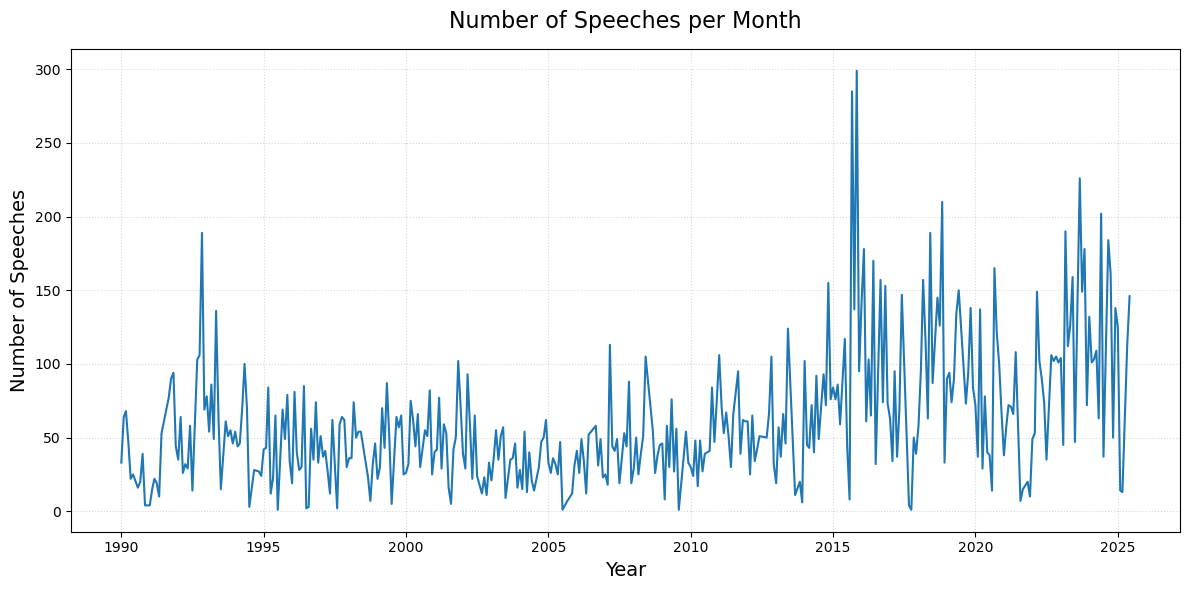

In [8]:
# 1. Group by "Yearmonth" and count the number of texts/rows
monthly_counts = data.groupby("YearMonth").size().reset_index(name="count")

# 2. Optional: Ensure your Yearmonth column is sorted chronologically
monthly_counts = monthly_counts.sort_values("YearMonth")
monthly_counts["YearMonth"] = monthly_counts["YearMonth"].dt.to_timestamp()

# 3. Plot the results
fig , ax = plt.subplots(figsize = (12,6) ) 
ax.plot(
    monthly_counts["YearMonth"],
    monthly_counts["count"],
    color = '#1f77b4', 
    linewidth = 1.5,
)

ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.title("Number of Speeches per Month" , fontsize=16 , pad = 15)
plt.xlabel("Year" , fontsize = 14)
plt.ylabel("Number of Speeches" , fontsize = 14)
plt.grid(True , linestyle= ":" , alpha = 0.5)

plt.tight_layout()
plt.show()

### SENTIMENT OVER TIME BY PARTY

In [5]:
parties = [
    'Cabinet',
    'FDP',
    'CDU/CSU',
    'SPD',
   # 'DP',
   # 'fraktionslos',
    'GRÜNE',
    'PDS',
    'LINKE',
    'AfD',
   # 'SPDCDU/CSU',
    'BSW'
]
data = data[data["Party"].isin(parties)]

In [6]:
ann_df = data
ann_df["decade"] = (ann_df["date"].dt.year // 10) * 10

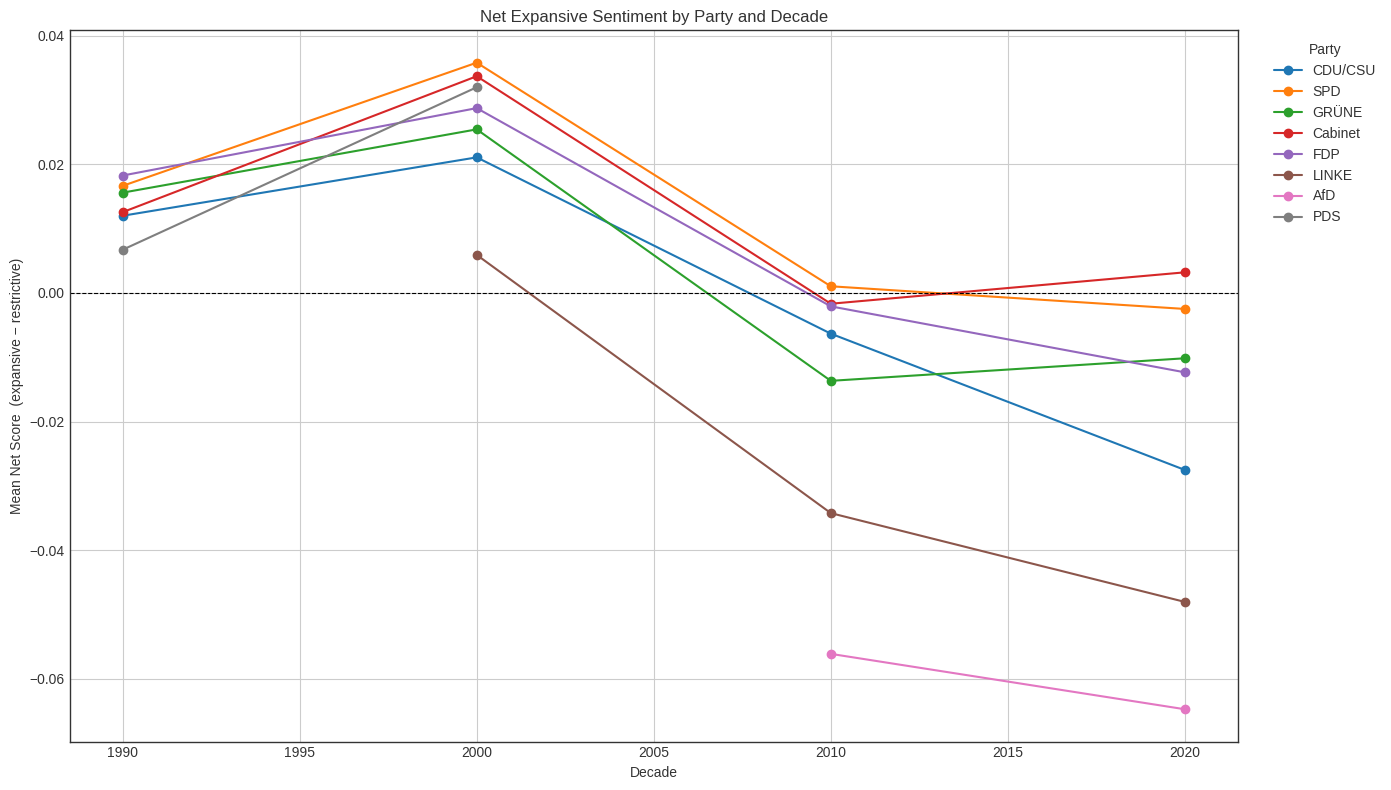

In [34]:

df_plot = ann_df.copy()
df_plot["net_expansive"] = (
    df_plot["similarity_expansive"] - df_plot["similarity_restrictive"]
)

party_decade_net = (
    df_plot.groupby(["decade", "Party"])["net_expansive"]
    .mean()
    .unstack("Party")
)

min_snippets_per_party = 30
party_counts_total = df_plot["Party"].value_counts()
main_parties = party_counts_total[
    party_counts_total >= min_snippets_per_party
].index.tolist()

# ---------------------------------------------------------
# 4. Plot one line per party, decades on x-axis
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 8))

party_decade_net[main_parties].plot(ax=ax, marker="o")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")

ax.set_title("Net Expansive Sentiment by Party and Decade")
ax.set_xlabel("Decade")
ax.set_ylabel("Mean Net Score  (expansive − restrictive)")
ax.legend(title="Party", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
#plt.savefig("party_decade_trend.png", dpi=150)
plt.show()

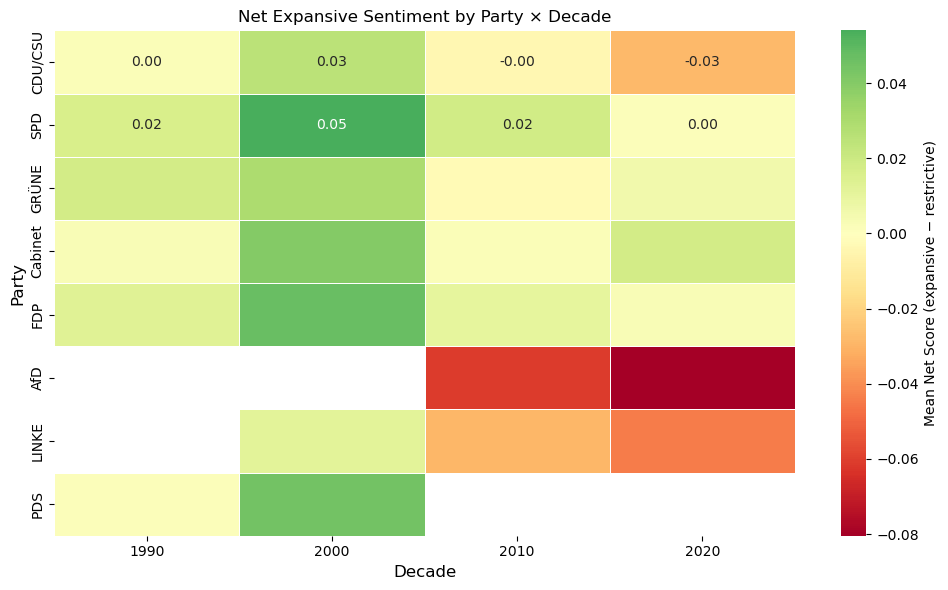

In [43]:
df_plot = ann_df.copy()
df_plot["net_expansive"] = (
    df_plot["similarity_expansive"] - df_plot["similarity_restrictive"]
)

party_decade_net = (
    df_plot.groupby(["decade", "Party"])["net_expansive"]
    .mean()
    .unstack("Party")          # rows = decade, cols = party
)


min_snippets_per_party = 30
party_counts_total = df_plot["Party"].value_counts()
main_parties = party_counts_total[
    party_counts_total >= min_snippets_per_party
].index.tolist()

fig, ax = plt.subplots(figsize=(10, 6))

sns.heatmap(
    party_decade_net[main_parties].T,   # .T → parties on rows
    cmap="RdYlGn",                      # red → yellow → green
    center=0,                           # 0 = neutral midpoint
    annot=True,                         # print values in cells
    fmt=".2f",                          # 2 decimals
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Mean Net Score (expansive − restrictive)"},
    ax=ax,
)

ax.set_title("Net Expansive Sentiment by Party × Decade")
ax.set_xlabel("Decade", fontsize=12)
ax.set_ylabel("Party", fontsize=12)

plt.tight_layout()
#plt.savefig("party_decade_heatmap.png", dpi=150)
plt.show()

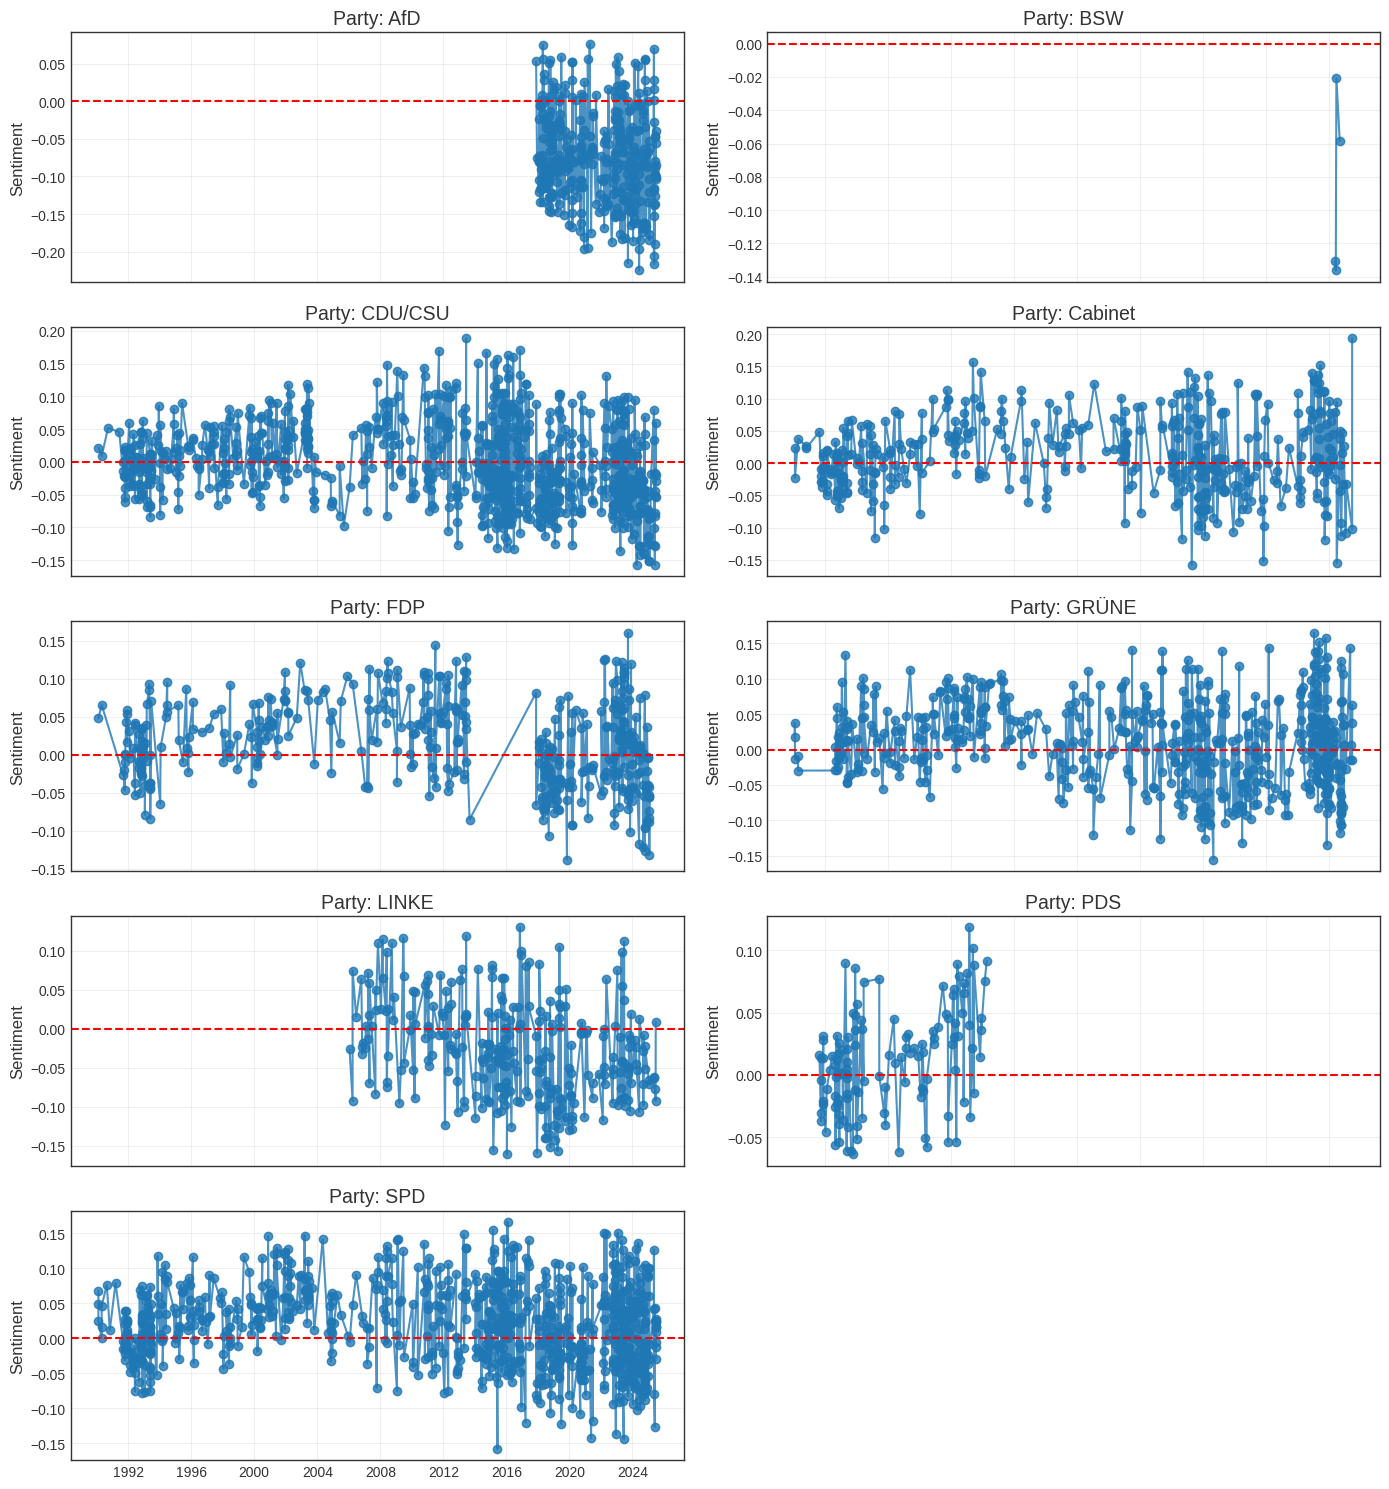

In [43]:
# 1. Get unique parties
parties = sorted(data["Party"].dropna().unique())
n_parties = len(parties)

# 2. Define grid dimensions: 2 columns, and enough rows to fit all parties
ncols = 2
nrows = math.ceil(n_parties / ncols)

fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols, figsize=(14, 3 * nrows), sharex=True
)

# Flatten the axes array so we can easily loop over it
axes_flat = axes.flatten()

# 3. Loop through each party and its corresponding subplot axis
for i, party in enumerate(parties):
  ax = axes_flat[i]
  party_data = data[data["Party"] == party]

  # Plot the party's sentiment
  ax.plot(
      party_data["date"],
      party_data["sentiment"],
      marker="o",
      linestyle="-",
      color="tab:blue",
      alpha=0.8,
      
  )

  # Horizontal line at y = 0
  ax.axhline(0, color="red", linestyle="--", linewidth=1.5)

  # Subplot styling
  ax.set_title(f"Party: {party}", fontsize=14)
  ax.set_ylabel("Sentiment", fontsize=12)
  ax.grid(True, alpha=0.3)

# 4. Hide any unused subplots (if n_parties is odd)
for j in range(i + 1, len(axes_flat)):
  fig.delaxes(axes_flat[j])

# 5. Final layout adjustments
plt.tight_layout()
plt.show()

### AVERAGE IMMIGRATION SENTIMENT BY POLITICAL PARTY - BAR PLOT

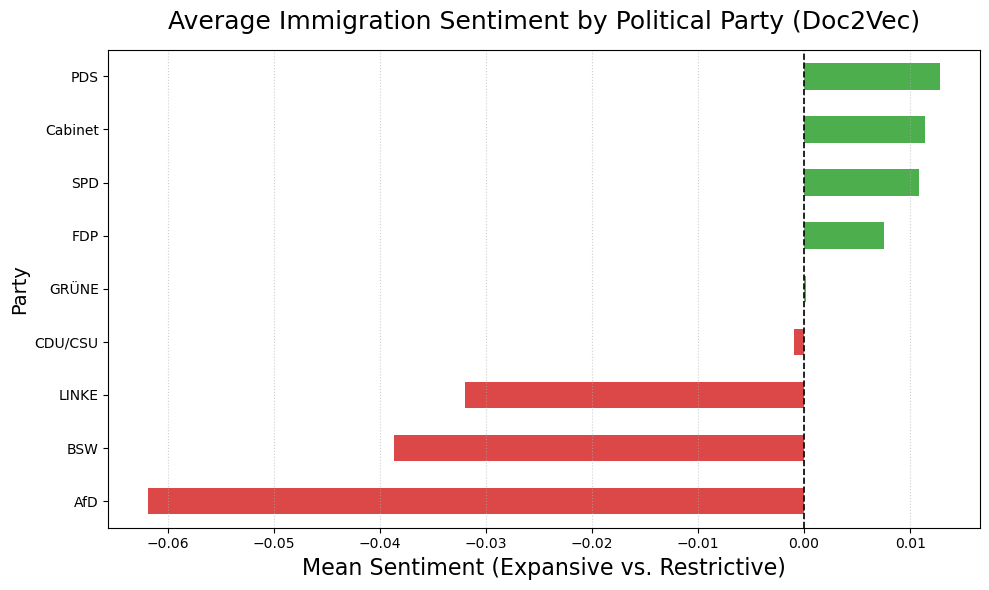

In [7]:
# 1. Calculate the mean sentiment per party and sort it
mean_sentiment = (
    data.groupby("Party")["sentiment"].mean().sort_values(ascending=True)
)

# 2. Create the horizontal bar plot
fig, ax = plt.subplots(figsize=(10, 6))

# Use different colors for positive (welcoming) vs negative (restrictive) sentiments
colors = ["tab:red" if val < 0 else "tab:green" for val in mean_sentiment.values]

mean_sentiment.plot(kind="barh", color=colors, ax=ax, alpha=0.85)

# 3. Add formatting and a vertical reference line at x = 0
ax.axvline(0, color="black", linestyle="--", linewidth=1.2)
ax.set_title(
    "Average Immigration Sentiment by Political Party (Doc2Vec)", fontsize=18, pad=15
)
ax.set_xlabel("Mean Sentiment (Expansive vs. Restrictive)", fontsize=16)
ax.set_ylabel("Party", fontsize=14)
ax.grid(axis="x", linestyle=":", alpha=0.6)



# 4. Display the plot
plt.tight_layout()
plt.show()

### MONTHLY PARLIAMENTARY IMMIGRATION SENTIMENT

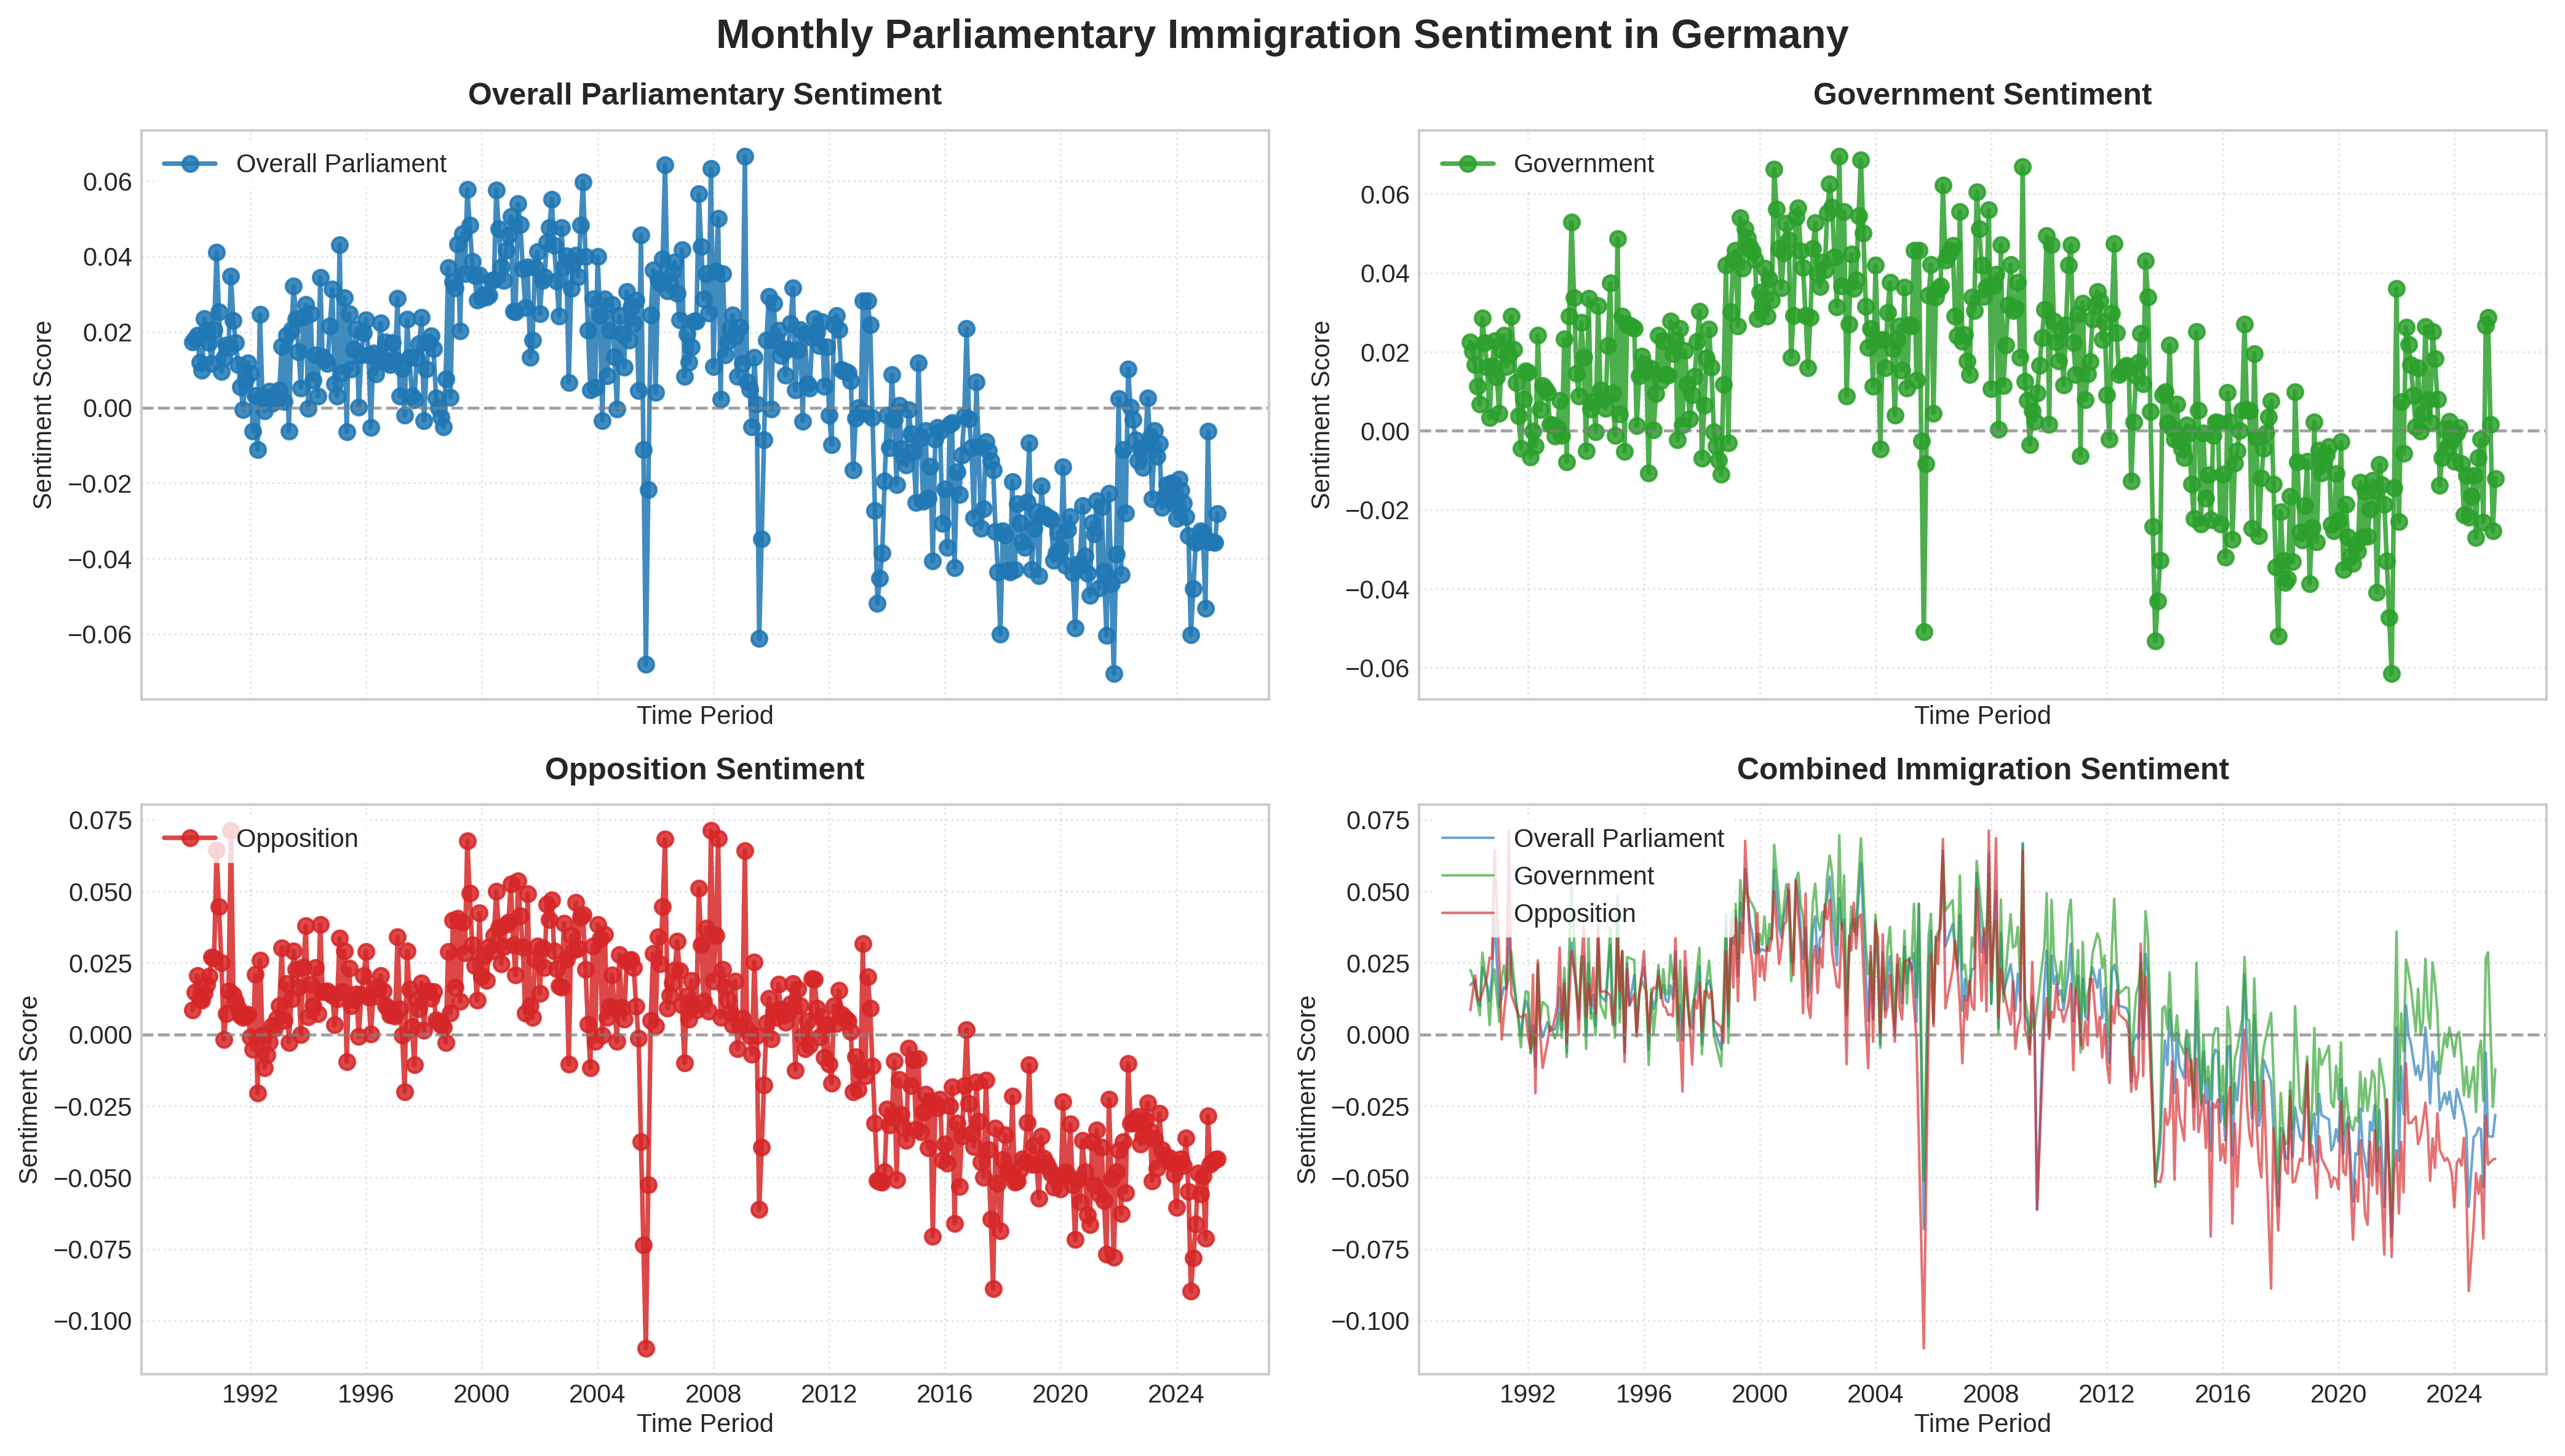

In [13]:
# Read data
sentiment = pd.read_csv("results/immigration_sentiment_monthly.csv")
# sentiment = sentiment[ (sentiment["Date"]>"2020-01-01")&(sentiment["Date"]<"2021-01-01")]

# Convert Date column to datetime
sentiment["Date"] = pd.to_datetime(sentiment["Date"])

# Set a professional style and color palette
plt.style.use(
    "seaborn-v0_8-whitegrid"
    if "seaborn-v0_8-whitegrid" in plt.style.available
    else "default"
)

# Create a 2x2 grid of subplots (4 plots total)
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 8), dpi=300, sharex=True)
axes_flat = axes.flatten()

# Configuration mapping for individual plots
plots_config = [
    {
        "col": "sentiment_gesamt",
        "color": "#1f77b4",
        "label": "Overall Parliament",
        "title": "Overall Parliamentary Sentiment",
        "marker": "o",
    },
    {
        "col": "sentiment_government",
        "color": "#2ca02c",
        "label": "Government",
        "title": "Government Sentiment",
        "marker": "o",
    },
    {
        "col": "sentiment_opposition",
        "color": "#d62728",
        "label": "Opposition",
        "title": "Opposition Sentiment",
        "marker": "o",
    },
]

# 1. Plot individual series on the first 3 subplots
for i, cfg in enumerate(plots_config):
  ax = axes_flat[i]
  ax.plot(
      sentiment["Date"],
      sentiment[cfg["col"]],
      linewidth=1.8,
      color=cfg["color"],
      label=cfg["label"],
      alpha=0.85,
      marker=cfg["marker"], # Uncomment if you want markers back
  )
  ax.axhline(0, color="gray", linestyle="--", linewidth=1.2, alpha=0.7)
  ax.set_title(cfg["title"], fontsize=12, fontweight="bold", pad=10)
  ax.set_ylabel("Sentiment Score", fontsize=10)
  ax.legend(frameon=True, facecolor="white", edgecolor="none", fontsize=10, loc="upper left")
  ax.grid(True, linestyle=":", alpha=0.5)

# 2. Plot all together on the 4th subplot
ax_all = axes_flat[3]
for cfg in plots_config:
  ax_all.plot(
      sentiment["Date"],
      sentiment[cfg["col"]],
      linewidth=1,
      color=cfg["color"],
      label=cfg["label"],
      alpha=0.65,
      
  )

ax_all.axhline(0, color="gray", linestyle="--", linewidth=1.2, alpha=0.7)
ax_all.set_title("Combined Immigration Sentiment", fontsize=12, fontweight="bold", pad=10)
ax_all.set_ylabel("Sentiment Score", fontsize=10)
ax_all.legend(frameon=True, facecolor="white", edgecolor="none", fontsize=10, loc="upper left")
ax_all.grid(True, linestyle=":", alpha=0.5)

# Set common X-label for bottom row or all
for ax in axes_flat:
  ax.set_xlabel("Time Period", fontsize=10, labelpad=2)

# Overall figure title
fig.suptitle(
    "Monthly Parliamentary Immigration Sentiment in Germany",
    fontsize=16,
    fontweight="bold",
    y=0.98,
)

plt.tight_layout()
plt.show()

### MONTHLY PARLIAMENTARY IMMIGRATION SENTIMENT

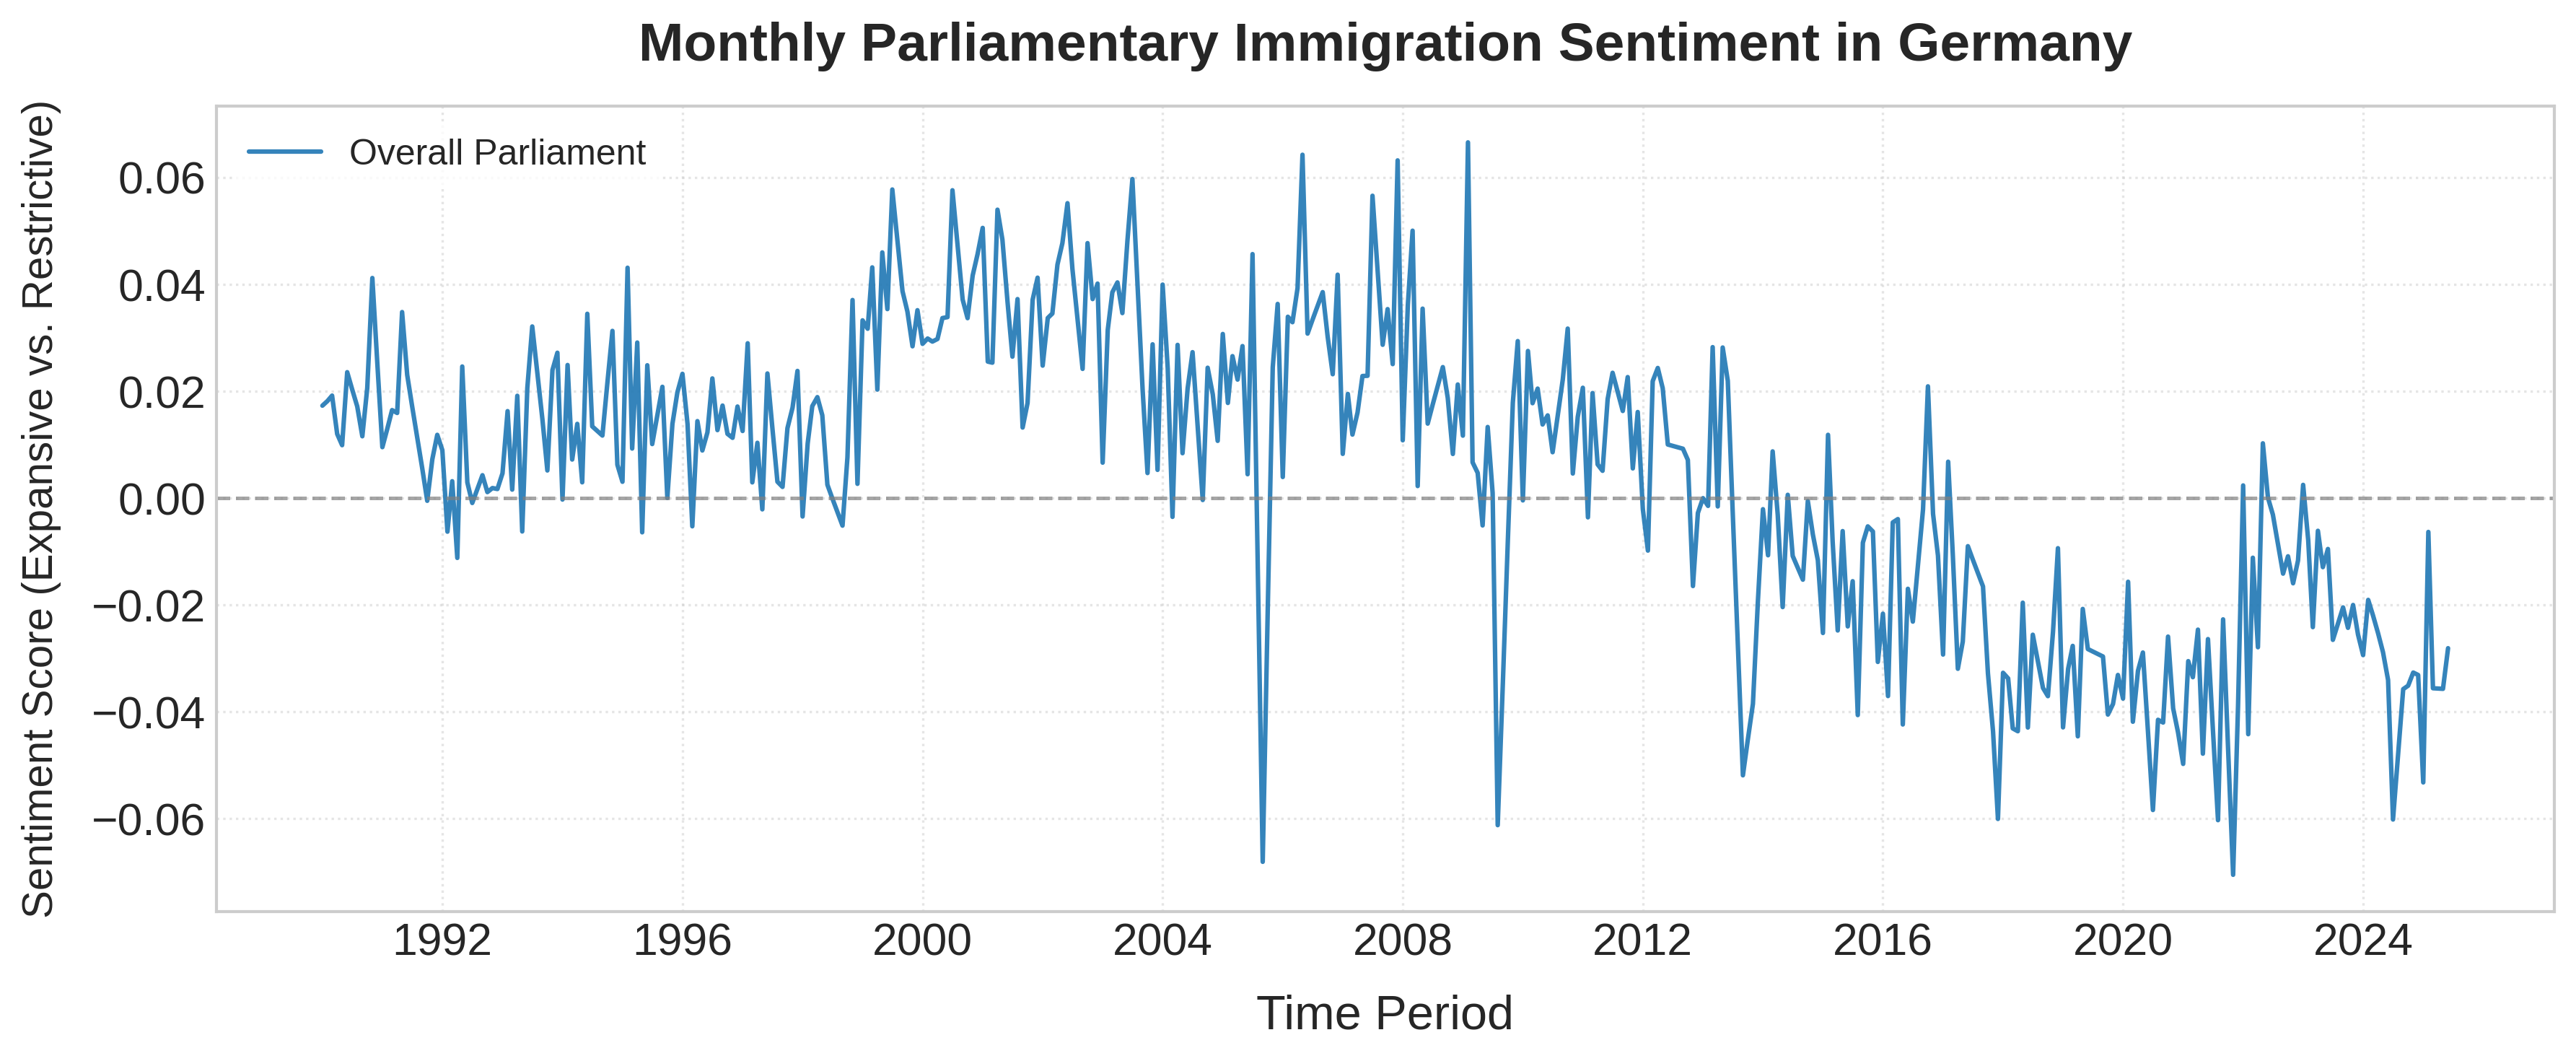

In [9]:
# Read data
sentiment = pd.read_csv("results/immigration_sentiment_monthly.csv")

# Convert Date column to datetime
sentiment["Date"] = pd.to_datetime(sentiment["Date"])

# Set a professional style and color palette
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
fig, ax = plt.subplots(figsize=(12, 5), dpi=300)

# Plot overall sentiment line
ax.plot(
    sentiment["Date"],
    sentiment["sentiment_gesamt"],
    linewidth=1.5,       # Slightly increased for better visibility
    color="#1f77b4",
    label="Overall Parliament",
    alpha=0.9,
)

# Reference line at zero
ax.axhline(0, color="gray", linestyle="--", linewidth=1.2, alpha=0.7)

# Clean, publication-quality labels and title (increased title/label sizes)
ax.set_title("Monthly Parliamentary Immigration Sentiment in Germany", fontsize=18, fontweight="bold", pad=15)
ax.set_xlabel("Time Period", fontsize=16, labelpad=10)
ax.set_ylabel("Sentiment Score (Expansive vs. Restrictive)", fontsize=14, labelpad=10)

# ==============================================================================
# INCREASE AXIS TICK VALUES (X and Y numbers/dates)
# ==============================================================================
ax.tick_params(axis="both", which="major", labelsize=15)  # Increase tick value size
# Option: ax.tick_params(axis="x", labelsize=13) or axis="y" individually if preferred

# Enhanced formatting for the legend and grid
ax.legend(frameon=True, facecolor="white", edgecolor="none", fontsize=12, loc="upper left")
ax.grid(True, linestyle=":", alpha=0.5)

# Adjust layout for neat rendering
plt.tight_layout()
plt.show()

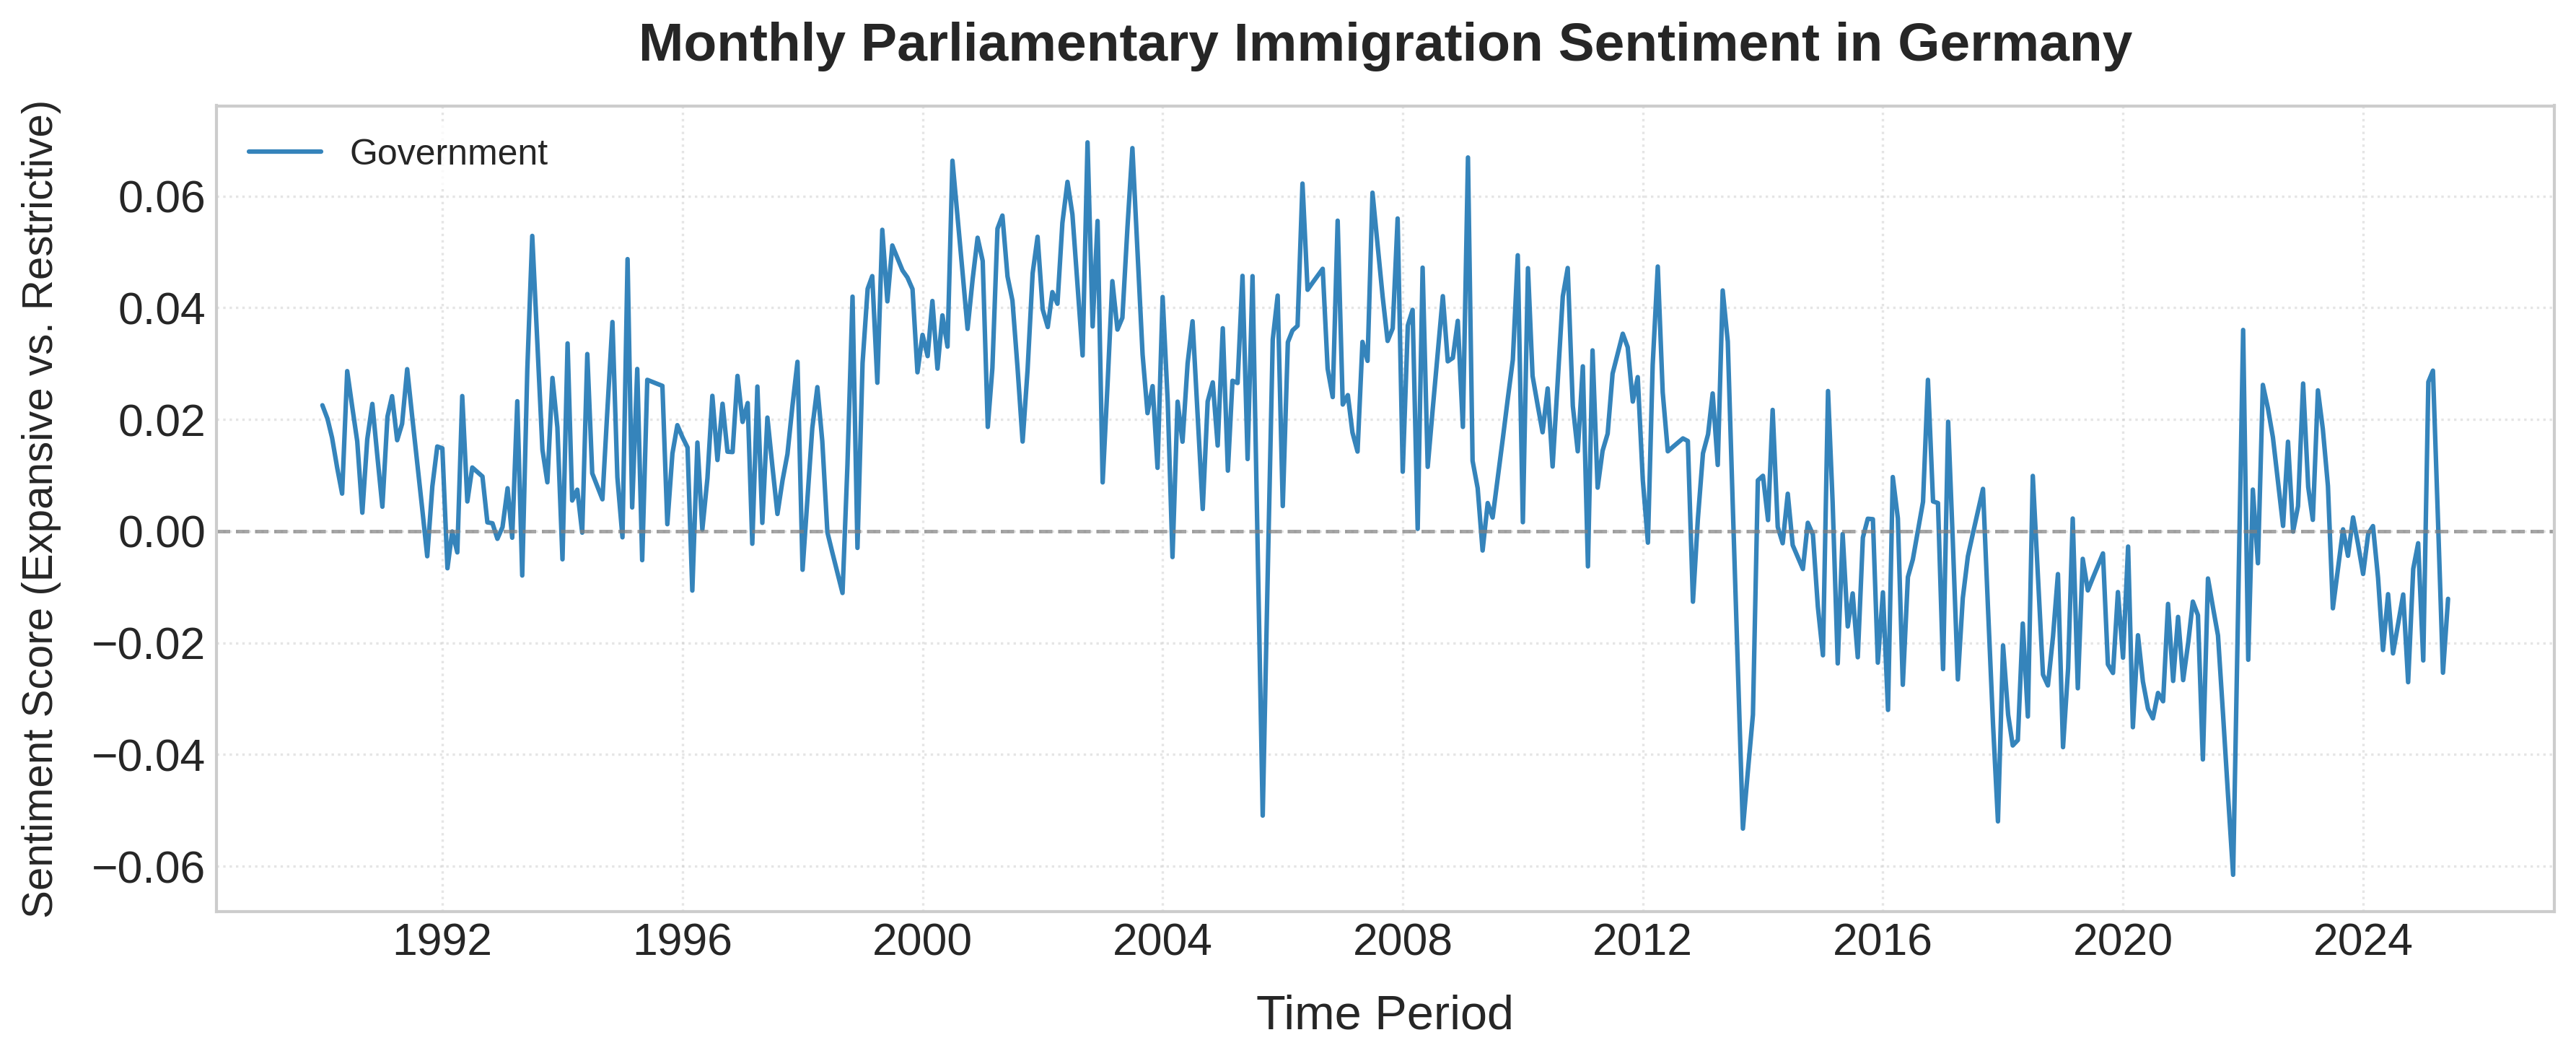

In [10]:
# Read data
sentiment = pd.read_csv("results/immigration_sentiment_monthly.csv")

# Convert Date column to datetime
sentiment["Date"] = pd.to_datetime(sentiment["Date"])

# Set a professional style and color palette
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
fig, ax = plt.subplots(figsize=(12, 5), dpi=300)

# Plot overall sentiment line
ax.plot(
    sentiment["Date"],
    sentiment["sentiment_government"],
    linewidth=1.5,       # Slightly increased for better visibility
    color="#1f77b4",
    label="Government",
    alpha=0.9,
)

# Reference line at zero
ax.axhline(0, color="gray", linestyle="--", linewidth=1.2, alpha=0.7)

# Clean, publication-quality labels and title (increased title/label sizes)
ax.set_title("Monthly Parliamentary Immigration Sentiment in Germany", fontsize=18, fontweight="bold", pad=15)
ax.set_xlabel("Time Period", fontsize=16, labelpad=10)
ax.set_ylabel("Sentiment Score (Expansive vs. Restrictive)", fontsize=14, labelpad=10)

# ==============================================================================
# INCREASE AXIS TICK VALUES (X and Y numbers/dates)
# ==============================================================================
ax.tick_params(axis="both", which="major", labelsize=15)  # Increase tick value size
# Option: ax.tick_params(axis="x", labelsize=13) or axis="y" individually if preferred

# Enhanced formatting for the legend and grid
ax.legend(frameon=True, facecolor="white", edgecolor="none", fontsize=12, loc="upper left")
ax.grid(True, linestyle=":", alpha=0.5)

# Adjust layout for neat rendering
plt.tight_layout()
plt.show()

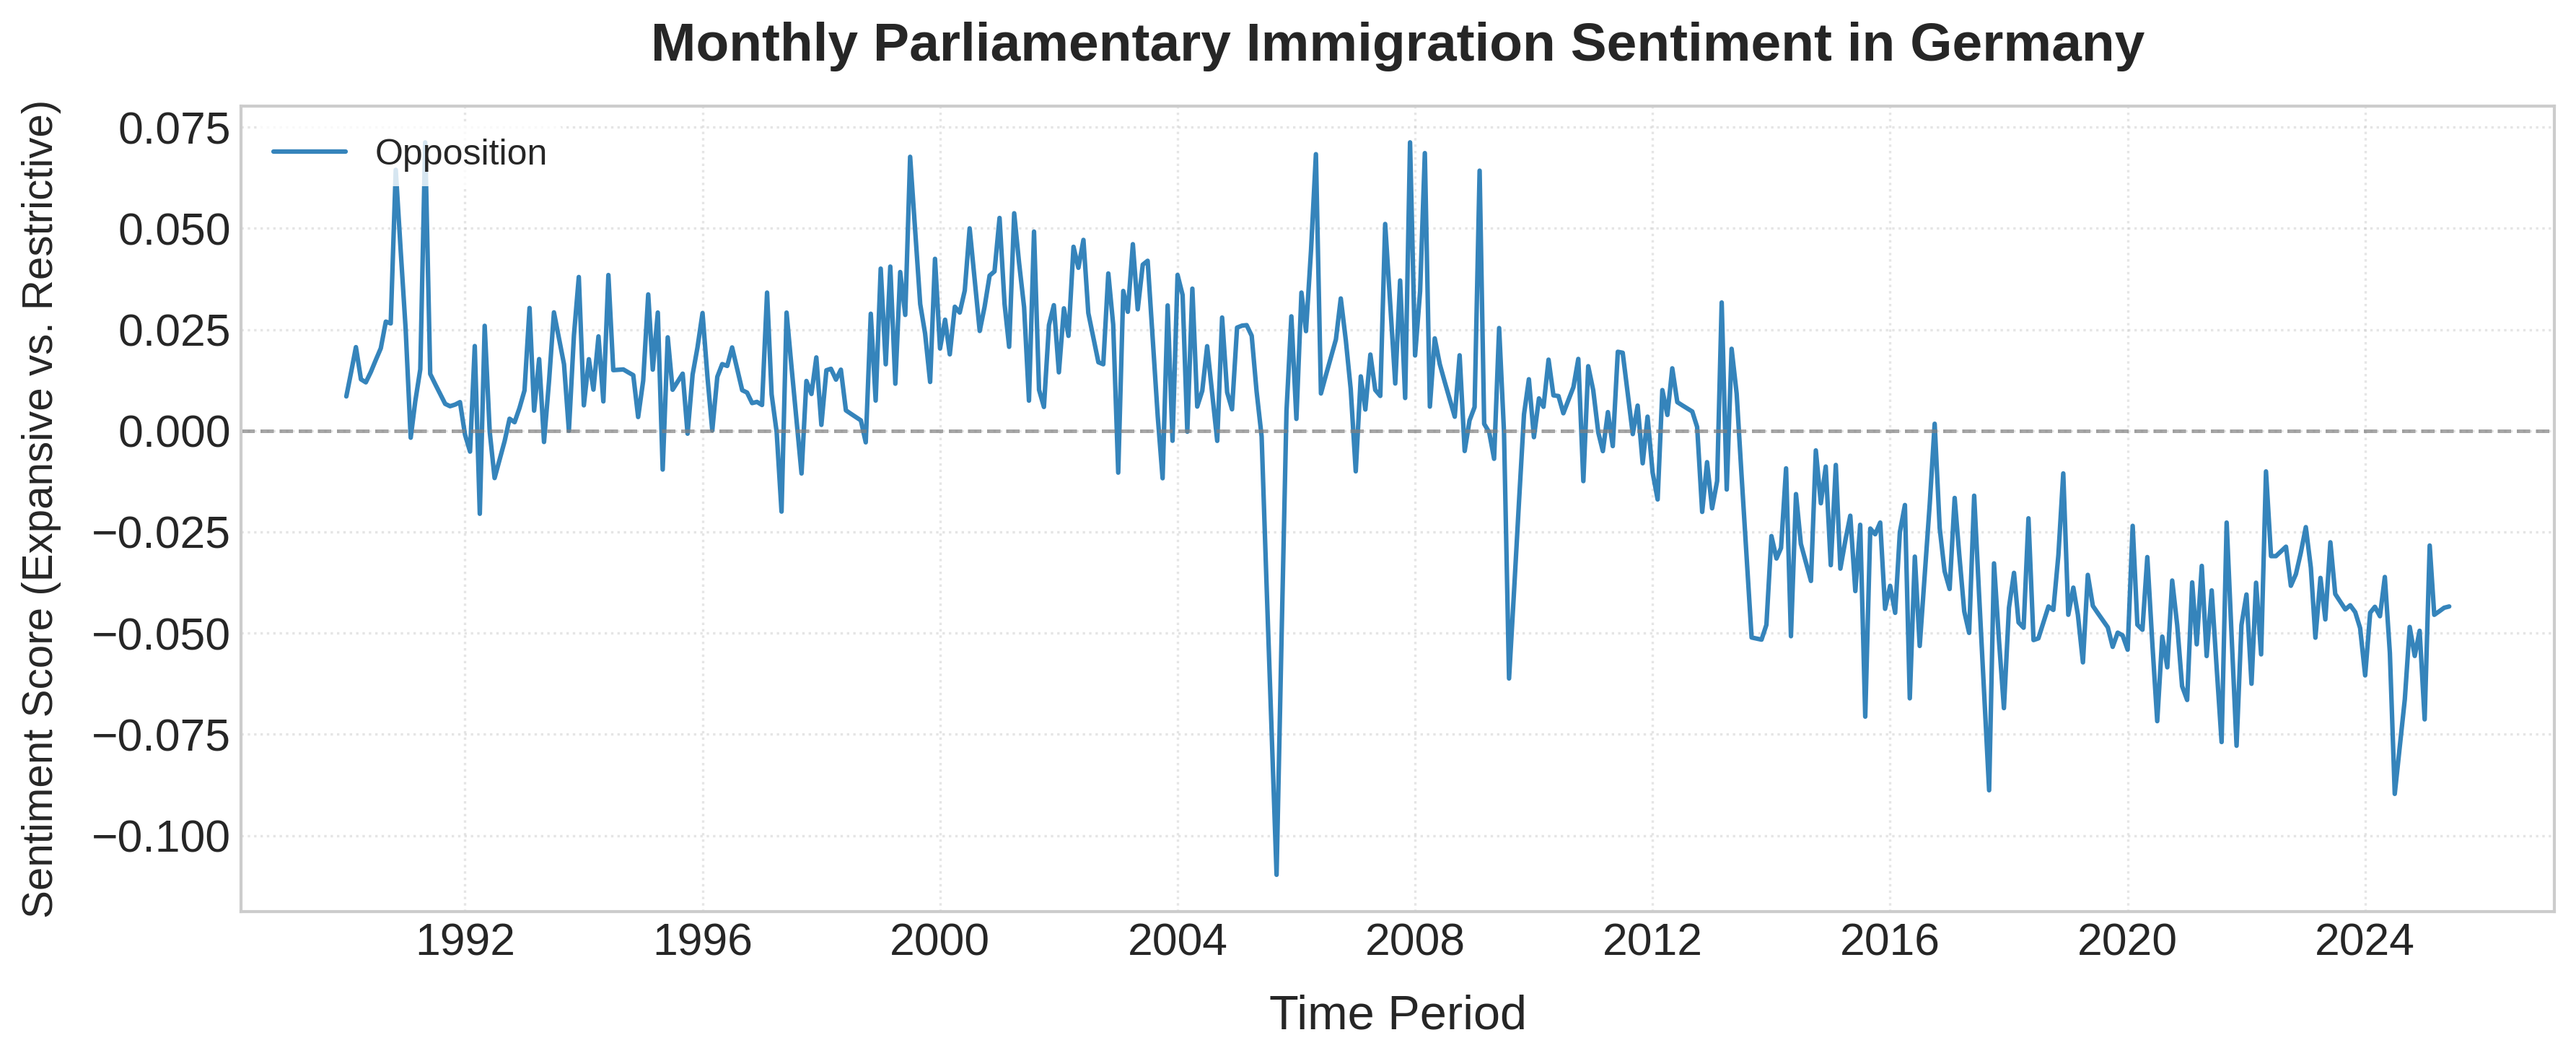

In [11]:
# Read data
sentiment = pd.read_csv("results/immigration_sentiment_monthly.csv")

# Convert Date column to datetime
sentiment["Date"] = pd.to_datetime(sentiment["Date"])

# Set a professional style and color palette
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
fig, ax = plt.subplots(figsize=(12, 5), dpi=300)

# Plot overall sentiment line
ax.plot(
    sentiment["Date"],
    sentiment["sentiment_opposition"],
    linewidth=1.5,       # Slightly increased for better visibility
    color="#1f77b4",
    label="Opposition",
    alpha=0.9,
)

# Reference line at zero
ax.axhline(0, color="gray", linestyle="--", linewidth=1.2, alpha=0.7)

# Clean, publication-quality labels and title (increased title/label sizes)
ax.set_title("Monthly Parliamentary Immigration Sentiment in Germany", fontsize=18, fontweight="bold", pad=15)
ax.set_xlabel("Time Period", fontsize=16, labelpad=10)
ax.set_ylabel("Sentiment Score (Expansive vs. Restrictive)", fontsize=14, labelpad=10)

# ==============================================================================
# INCREASE AXIS TICK VALUES (X and Y numbers/dates)
# ==============================================================================
ax.tick_params(axis="both", which="major", labelsize=15)  # Increase tick value size
# Option: ax.tick_params(axis="x", labelsize=13) or axis="y" individually if preferred

# Enhanced formatting for the legend and grid
ax.legend(frameon=True, facecolor="white", edgecolor="none", fontsize=12, loc="upper left")
ax.grid(True, linestyle=":", alpha=0.5)

# Adjust layout for neat rendering
plt.tight_layout()
plt.show()

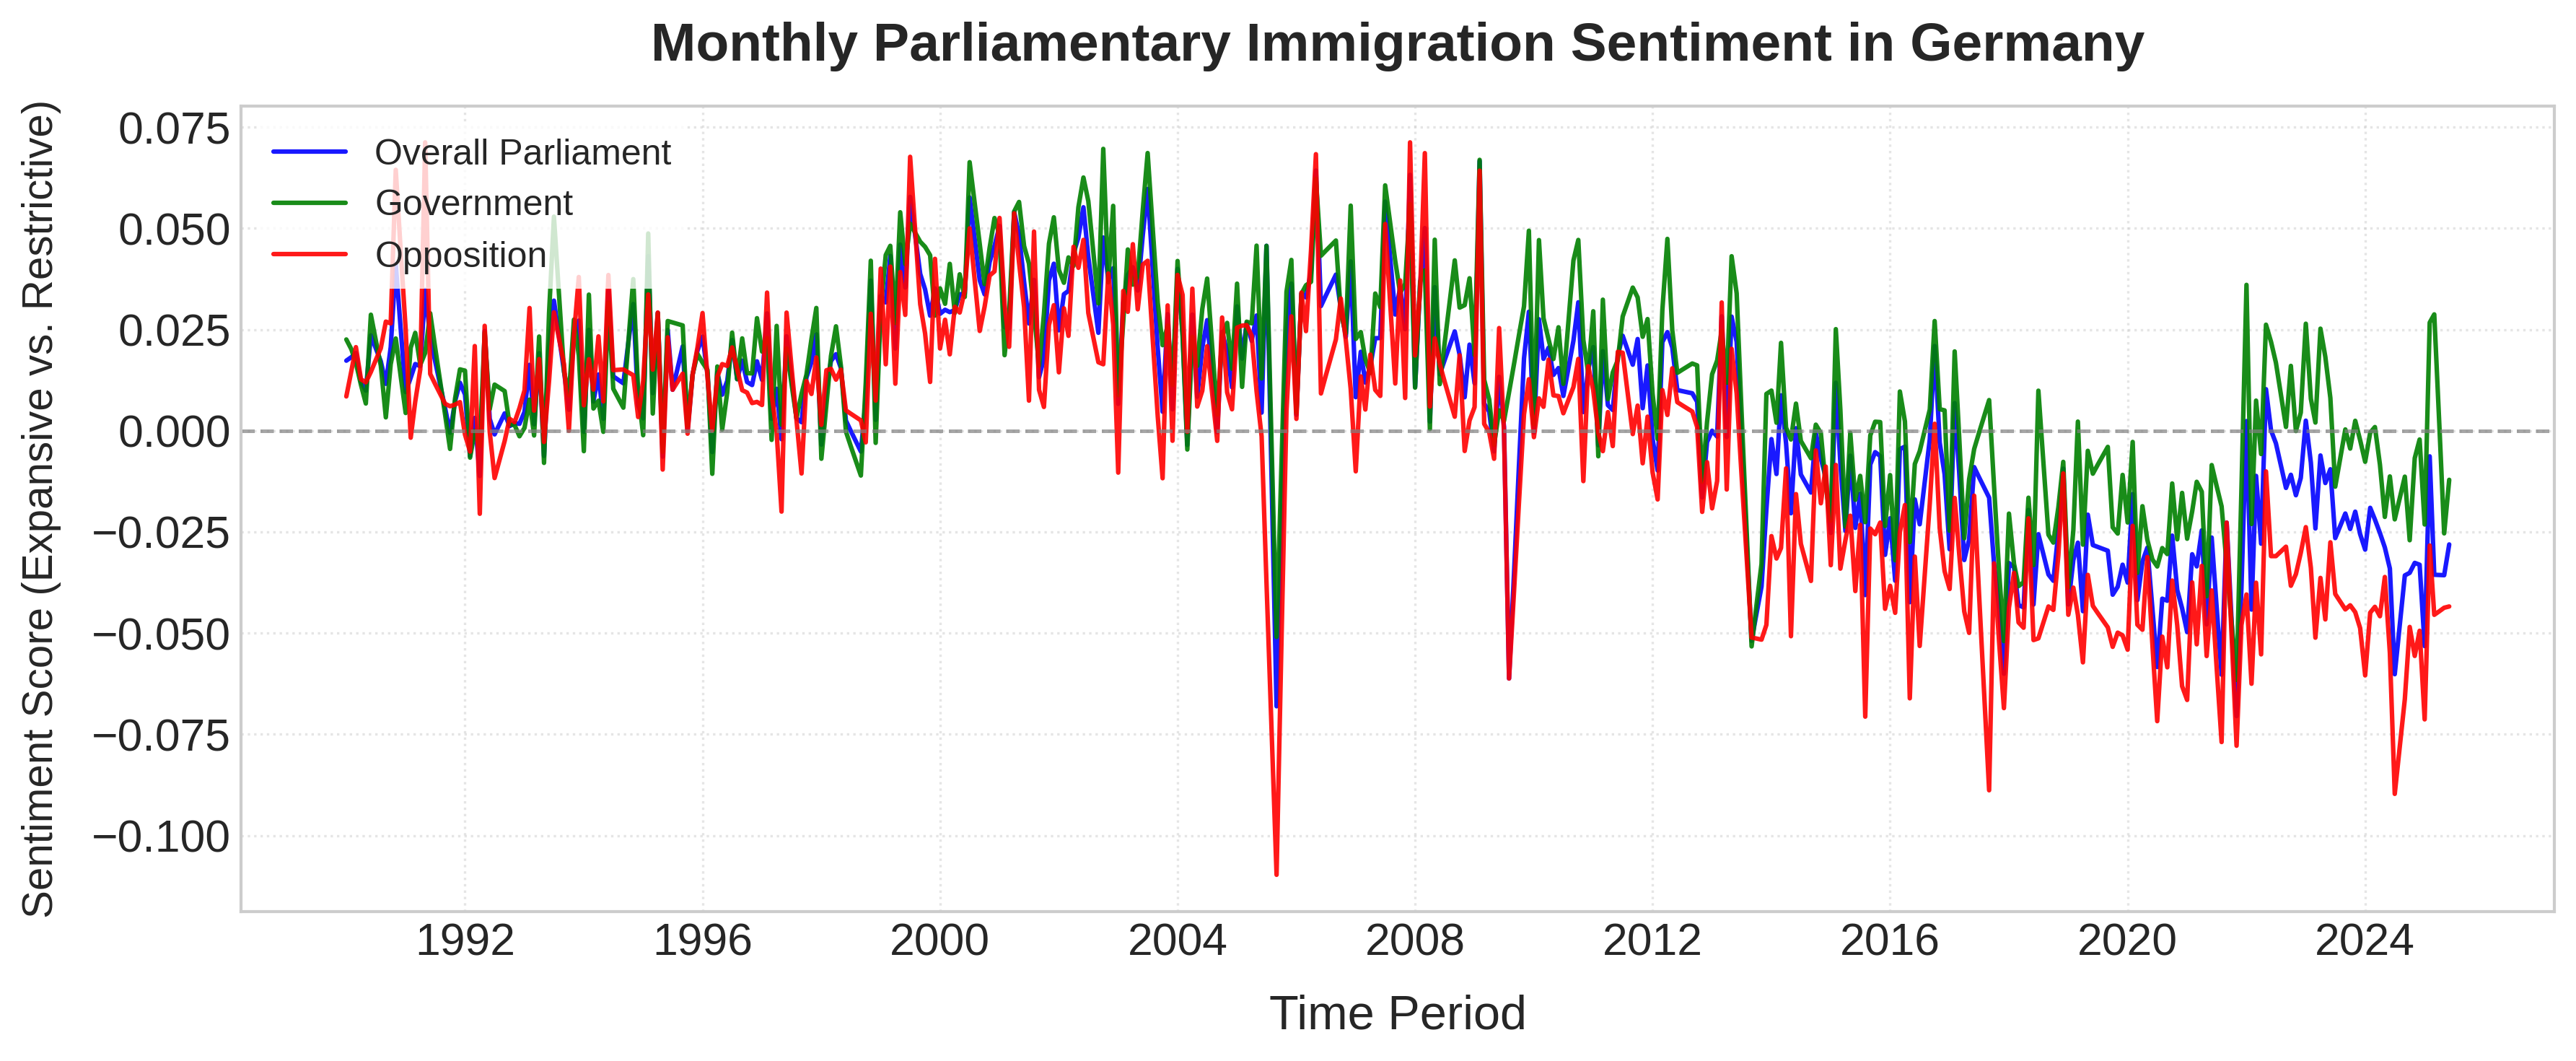

In [18]:
# Read data
sentiment = pd.read_csv("results/immigration_sentiment_monthly.csv")

# Convert Date column to datetime
sentiment["Date"] = pd.to_datetime(sentiment["Date"])

# Set a professional style and color palette
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
fig, ax = plt.subplots(figsize=(12, 5), dpi=300)

# Plot overall sentiment line
ax.plot(
    sentiment["Date"],
    sentiment["sentiment_gesamt"],
    linewidth=1.5,       # Slightly increased for better visibility
    color="blue",
    label="Overall Parliament",
    alpha=0.9,
)

ax.plot(
    sentiment["Date"],
    sentiment["sentiment_government"],
    linewidth=1.5,       # Slightly increased for better visibility
    color="green",
    label="Government",
    alpha=0.9,
)

ax.plot(
    sentiment["Date"],
    sentiment["sentiment_opposition"],
    linewidth=1.5,       # Slightly increased for better visibility
    color="red",
    label="Opposition",
    alpha=0.9,
)



# Reference line at zero
ax.axhline(0, color="gray", linestyle="--", linewidth=1.2, alpha=0.7)

# Clean, publication-quality labels and title (increased title/label sizes)
ax.set_title("Monthly Parliamentary Immigration Sentiment in Germany", fontsize=18, fontweight="bold", pad=15)
ax.set_xlabel("Time Period", fontsize=16, labelpad=10)
ax.set_ylabel("Sentiment Score (Expansive vs. Restrictive)", fontsize=14, labelpad=10)

# ==============================================================================
# INCREASE AXIS TICK VALUES (X and Y numbers/dates)
# ==============================================================================
ax.tick_params(axis="both", which="major", labelsize=15)  # Increase tick value size
# Option: ax.tick_params(axis="x", labelsize=13) or axis="y" individually if preferred

# Enhanced formatting for the legend and grid
ax.legend(frameon=True, facecolor="white", edgecolor="none", fontsize=12, loc="upper left")
ax.grid(True, linestyle=":", alpha=0.5)

# Adjust layout for neat rendering
plt.tight_layout()
plt.show()

### IMMIGRATION SOLIDARITY NET SCORE - GOVERNMENT VS. OPPOSITION

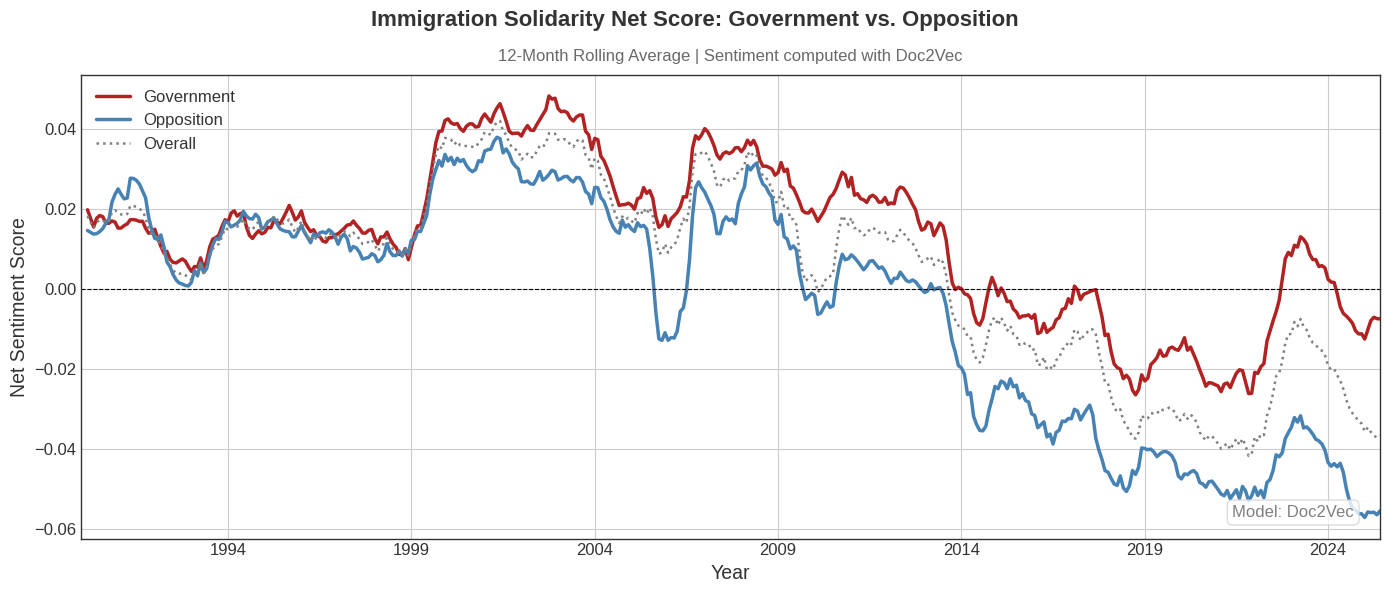

In [37]:
# 1. Handle index safely (convert to datetime and slice)
df_plot = sentiment.copy()
if 'Date' in df_plot.columns:
    df_plot['Date'] = pd.to_datetime(df_plot['Date'])
    df_plot.set_index('Date', inplace=True)
else:
    df_plot.index = pd.to_datetime(df_plot.index)

#df_plot = df_plot.loc["1990-01-01":].sort_index()

# 2. Create the plot
fig, ax = plt.subplots(figsize=(14, 6))

# Plot 12-month rolling averages
df_plot["sentiment_government"].rolling(
    window=12, min_periods=3
).mean().plot(ax=ax, color="firebrick", linewidth=2.5, label="Government")

df_plot["sentiment_opposition"].rolling(
    window=12, min_periods=3
).mean().plot(ax=ax, color="steelblue", linewidth=2.5, label="Opposition")

df_plot["sentiment_gesamt"].rolling(
    window=12, min_periods=3
).mean().plot(
    ax=ax, color="gray", linewidth=1.8, linestyle=":", label="Overall"
)

# 3. Styling, formatting, and larger fonts
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")

# Main Title & Subtitle mentioning the model
plt.suptitle(
    "Immigration Solidarity Net Score: Government vs. Opposition",
    fontsize=16,
    fontweight="bold",
    y=0.98,
)
ax.set_title(
    "12-Month Rolling Average | Sentiment computed with Doc2Vec",
    fontsize=12,
    color="dimgray",
    pad=10,
)

ax.set_xlabel("Year", fontsize=14)
ax.set_ylabel("Net Sentiment Score", fontsize=14)

# Tick labels
ax.tick_params(axis="both", which="major", labelsize=12)

# Legend font size
ax.legend(fontsize=12, loc="upper left")

# Model Badge / Watermark in the plot corner
ax.text(
    0.98,
    0.04,
    "Model: Doc2Vec",
    transform=ax.transAxes,
    fontsize=12,
    color="gray",
    ha="right",
    va="bottom",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="lightgray", alpha=0.8),
)

plt.tight_layout()
#plt.savefig("gov_vs_opposition_monthly.png", dpi=150)
plt.show()

### IMMIGRATION SENTIMENT ANALYSIS

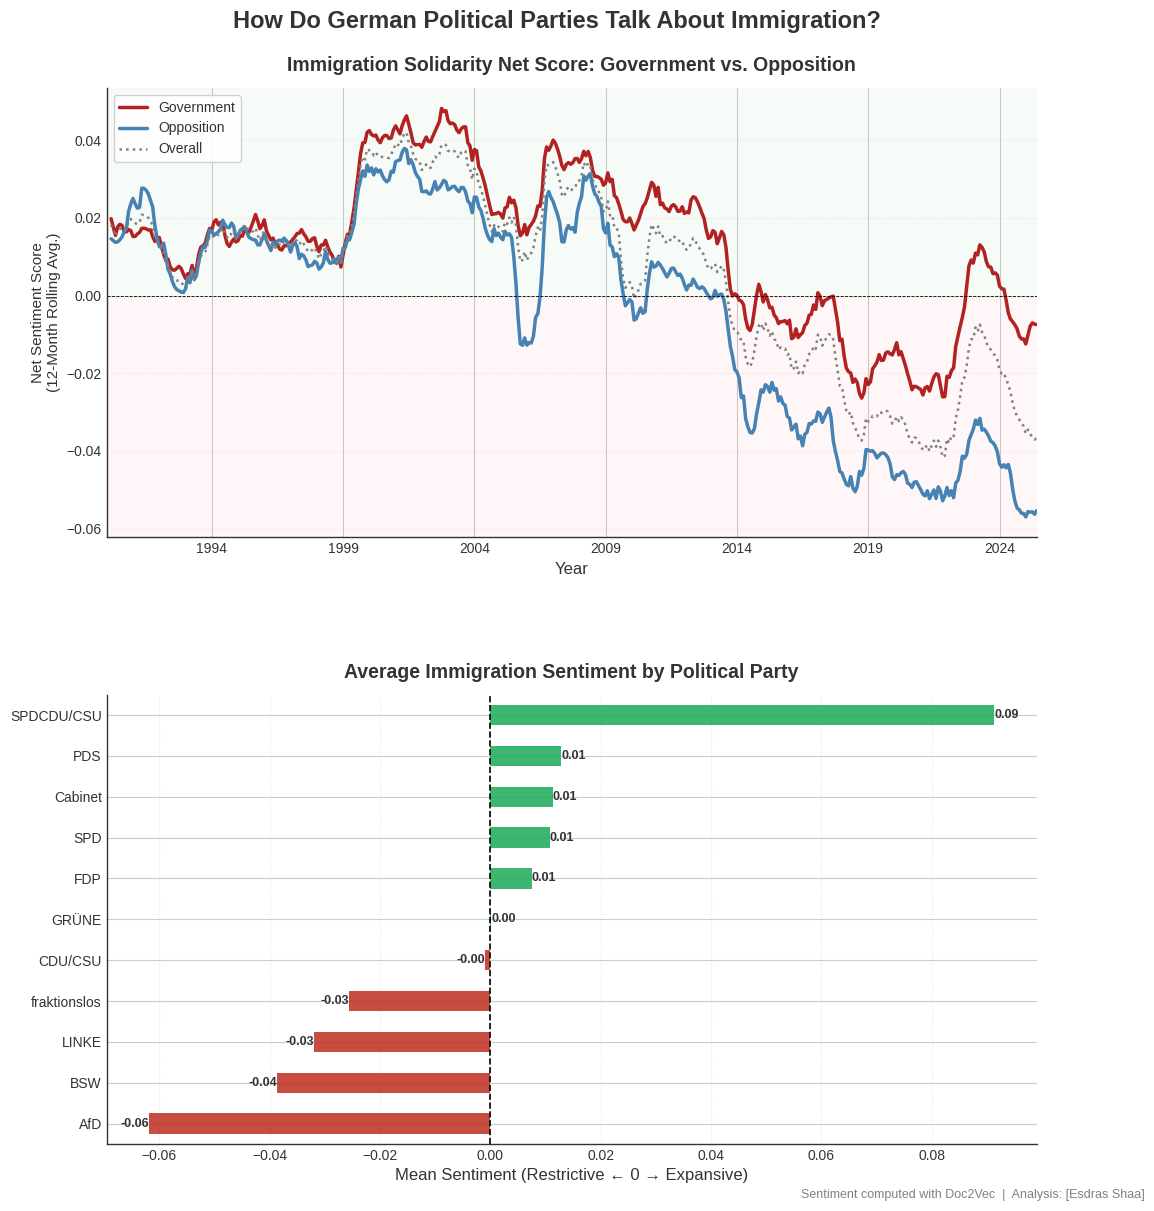

In [38]:
# =========================================================
# 0. Global style
# =========================================================
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["axes.edgecolor"] = "#333333"
plt.rcParams["axes.labelcolor"] = "#333333"
plt.rcParams["text.color"] = "#333333"
plt.rcParams["xtick.color"] = "#333333"
plt.rcParams["ytick.color"] = "#333333"

# =========================================================
# 1. Prepare data
# =========================================================
df_plot = sentiment.copy()
if 'Date' in df_plot.columns:
    df_plot['Date'] = pd.to_datetime(df_plot['Date'])
    df_plot.set_index('Date', inplace=True)
else:
    df_plot.index = pd.to_datetime(df_plot.index)

mean_sentiment = (
    data.groupby("Party")["sentiment"].mean().sort_values(ascending=True)
)

# =========================================================
# 2. Create 2x1 subplot grid
# =========================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

# ---------------------------------------------------------
# Top plot: rolling sentiment over time
# ---------------------------------------------------------
df_plot["sentiment_government"].rolling(window=12, min_periods=3).mean().plot(
    ax=ax1, color="firebrick", linewidth=2.5, label="Government"
)
df_plot["sentiment_opposition"].rolling(window=12, min_periods=3).mean().plot(
    ax=ax1, color="steelblue", linewidth=2.5, label="Opposition"
)
df_plot["sentiment_gesamt"].rolling(window=12, min_periods=3).mean().plot(
    ax=ax1, color="gray", linewidth=1.8, linestyle=":", label="Overall"
)

# Subtle background shading for positive/negative regions
ymin, ymax = ax1.get_ylim()
ax1.axhspan(0, ymax, color="green", alpha=0.03)
ax1.axhspan(ymin, 0, color="red", alpha=0.03)
ax1.set_ylim(ymin, ymax)

ax1.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax1.grid(axis="y", linestyle=":", alpha=0.4)

ax1.set_title(
    "Immigration Solidarity Net Score: Government vs. Opposition",
    fontsize=14, fontweight="bold", pad=12
)
ax1.set_xlabel("Year", fontsize=12)
ax1.set_ylabel("Net Sentiment Score\n(12-Month Rolling Avg.)", fontsize=11)
ax1.tick_params(axis="both", labelsize=10)
ax1.legend(fontsize=10, loc="upper left", frameon=True, framealpha=0.9)

# Cleaner date ticks
#ax1.xaxis.set_major_locator(mdates.YearLocator(2))
#ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# ---------------------------------------------------------
# Bottom plot: mean sentiment by party
# ---------------------------------------------------------
colors = ["#c0392b" if val < 0 else "#27ae60" for val in mean_sentiment.values]
mean_sentiment.plot(kind="barh", color=colors, ax=ax2, alpha=0.9)

# Value labels at the end of each bar
for i, v in enumerate(mean_sentiment.values):
    ax2.text(
        v, i, f"{v:.2f}",
        va="center",
        ha="left" if v >= 0 else "right",
        fontsize=9,
        color="#333333",
        fontweight="bold",
    )

ax2.axvline(0, color="black", linestyle="--", linewidth=1.2)
ax2.grid(axis="x", linestyle=":", alpha=0.5)

ax2.set_title(
    "Average Immigration Sentiment by Political Party",
    fontsize=14, fontweight="bold", pad=12
)
ax2.set_xlabel("Mean Sentiment (Restrictive ← 0 → Expansive)", fontsize=12)
ax2.set_ylabel("")
ax2.tick_params(axis="both", labelsize=10)

# ---------------------------------------------------------
# Clean spines for both plots
# ---------------------------------------------------------
for ax in (ax1, ax2):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# =========================================================
# 3. Figure-level title, spacing & source note
# =========================================================
fig.suptitle(
    "How Do German Political Parties Talk About Immigration?",
    fontsize=17, fontweight="bold", y=0.995
)

plt.subplots_adjust(hspace=0.35, top=0.93, bottom=0.05)

fig.text(
    0.99, 0.005,
    "Sentiment computed with Doc2Vec  |  Analysis: [Esdras Shaa]",
    ha="right", fontsize=9, color="gray"
)


# =========================================================
# 4. Save & show
# =========================================================
#plt.savefig("sentiment_analysis_linkedin.png", dpi=300, bbox_inches="tight")

plt.show()

### DATA LOADING, FILTERING BY DATE RANGE, AND SAVING

In [ ]:
sentiment = pd.read_csv("results/immigration_sentiment_monthly.csv")
# Convert Date to datetime
sentiment["Date"] = pd.to_datetime(sentiment["Date"])

# Keep observations from 2006-01-01 to 2019-10-01
sentiment_2006_2019 = sentiment[
    (sentiment["Date"] >= "2006-01-01") &
    (sentiment["Date"] <= "2025-06-01")
].copy()


# Save the filtered data
sentiment_2006_2019.to_csv(
    "results/immigration_sentiment_monthly_2006_2025_doc2vec.csv",
    index=False
)

### Test the model

In [19]:
filter_speech.columns

Index(['Unnamed: 0', 'date', 'Party', 'speech_identification_ent',
       'text_preprocessed_lemmatized', 'similarity_expansive',
       'similarity_restrictive', 'immigration_position'],
      dtype='object')

In [25]:
filter_speech = pd.read_csv("./results/filter_speeches.csv")
positiv_speech = filter_speech[ filter_speech['immigration_position'] == 'True' ]
negativ_speech = filter_speech[ filter_speech['immigration_position'] == 'False' 
]

(len(positiv_speech), len(negativ_speech))


(62, 26)

In [26]:
# Select all rows in 'data' whose text matches ANY value in 'filter_speech'
matched_data_positiv = data[
    data["text_preprocessed_lemmatized"].isin(
        positiv_speech["text_preprocessed_lemmatized"]
    )
]

len(
    matched_data_positiv[
        matched_data_positiv["sentiment"] > 0
    ]
) / len(matched_data_positiv)*100

79.16666666666666

In [14]:
# Select all rows in 'data' whose text matches ANY value in 'filter_speech'
matched_data_negativ = data[
    data["text_preprocessed_lemmatized"].isin(
        negativ_speech["text_preprocessed_lemmatized"]
    )
]

len(
    matched_data_negativ[
        matched_data_negativ["sentiment"] < 0
    ]
) / len(matched_data_negativ)*100

80.76923076923077

In [15]:
len(data)

23108

In [ ]:
len(# If you are using Python/Pandas (based on the syntax in your prompt):
# Pandas uses '~' and '.isin()'
data[data["text_preprocessed_lemmatized"].isin(positiv_speech["text_preprocessed_lemmatized"])])

48

In [27]:
import pandas as pd

# ============================================================
# 1. Load filtered immigration speeches
# ============================================================

filter_speech = pd.read_csv("./results/filter_speeches.csv")

# Make sure immigration_position is treated consistently
filter_speech["immigration_position"] = (
    filter_speech["immigration_position"]
    .astype(str)
    .str.strip()
)

# ============================================================
# 2. Split speeches into positive and negative positions
# ============================================================

positiv_speech = filter_speech[
    filter_speech["immigration_position"].str.lower() == "true"
].copy()

negativ_speech = filter_speech[
    filter_speech["immigration_position"].str.lower() == "false"
].copy()

print("Positive speeches:", len(positiv_speech))
print("Negative speeches:", len(negativ_speech))


# ============================================================
# 3. Match positive speeches with the sentiment data
# ============================================================

matched_data_positiv = data[
    data["text_preprocessed_lemmatized"].isin(
        positiv_speech["text_preprocessed_lemmatized"]
    )
].copy()

# Positive sentiment among positive-position speeches
positive_sentiment_matches = matched_data_positiv[
    matched_data_positiv["sentiment"] > 0
]

# Negative sentiment among positive-position speeches
negative_sentiment_matches = matched_data_positiv[
    matched_data_positiv["sentiment"] < 0
]

# Neutral sentiment
neutral_sentiment_matches = matched_data_positiv[
    matched_data_positiv["sentiment"] == 0
]


# ============================================================
# 4. Match negative speeches with the sentiment data
# ============================================================

matched_data_negativ = data[
    data["text_preprocessed_lemmatized"].isin(
        negativ_speech["text_preprocessed_lemmatized"]
    )
].copy()

# Negative sentiment among negative-position speeches
negative_sentiment_matches_neg = matched_data_negativ[
    matched_data_negativ["sentiment"] < 0
]

# Positive sentiment among negative-position speeches
positive_sentiment_matches_neg = matched_data_negativ[
    matched_data_negativ["sentiment"] > 0
]

# Neutral sentiment
neutral_sentiment_matches_neg = matched_data_negativ[
    matched_data_negativ["sentiment"] == 0
]


# ============================================================
# 5. Calculate percentages
# ============================================================

def percentage(n, total):
    if total == 0:
        return 0.0
    return 100 * n / total


# Positive-position speeches
n_pos = len(matched_data_positiv)

pos_correct = len(positive_sentiment_matches)
pos_wrong = len(negative_sentiment_matches)
pos_neutral = len(neutral_sentiment_matches)

pos_correct_pct = percentage(pos_correct, n_pos)
pos_wrong_pct = percentage(pos_wrong, n_pos)
pos_neutral_pct = percentage(pos_neutral, n_pos)


# Negative-position speeches
n_neg = len(matched_data_negativ)

neg_correct = len(negative_sentiment_matches_neg)
neg_wrong = len(positive_sentiment_matches_neg)
neg_neutral = len(neutral_sentiment_matches_neg)

neg_correct_pct = percentage(neg_correct, n_neg)
neg_wrong_pct = percentage(neg_wrong, n_neg)
neg_neutral_pct = percentage(neg_neutral, n_neg)


# ============================================================
# 6. Print results
# ============================================================

print("\n" + "=" * 60)
print("SENTIMENT VALIDATION")
print("=" * 60)

print("\nPOSITIVE IMMIGRATION POSITION")
print("-" * 40)
print(f"Matched speeches:              {n_pos}")
print(f"Positive sentiment:            {pos_correct} ({pos_correct_pct:.2f}%)")
print(f"Negative sentiment:            {pos_wrong} ({pos_wrong_pct:.2f}%)")
print(f"Neutral sentiment:             {pos_neutral} ({pos_neutral_pct:.2f}%)")

print("\nNEGATIVE IMMIGRATION POSITION")
print("-" * 40)
print(f"Matched speeches:              {n_neg}")
print(f"Negative sentiment:            {neg_correct} ({neg_correct_pct:.2f}%)")
print(f"Positive sentiment:            {neg_wrong} ({neg_wrong_pct:.2f}%)")
print(f"Neutral sentiment:             {neg_neutral} ({neg_neutral_pct:.2f}%)")


# ============================================================
# 7. Overall directional agreement
# ============================================================

total_matched = n_pos + n_neg
directional_agreement = pos_correct + neg_correct

print("\n" + "=" * 60)
print("OVERALL")
print("=" * 60)

print(f"Total matched speeches:         {total_matched}")
print(
    f"Directional agreement:         "
    f"{directional_agreement} "
    f"({percentage(directional_agreement, total_matched):.2f}%)"
)

Positive speeches: 62
Negative speeches: 26

SENTIMENT VALIDATION

POSITIVE IMMIGRATION POSITION
----------------------------------------
Matched speeches:              48
Positive sentiment:            38 (79.17%)
Negative sentiment:            10 (20.83%)
Neutral sentiment:             0 (0.00%)

NEGATIVE IMMIGRATION POSITION
----------------------------------------
Matched speeches:              26
Negative sentiment:            21 (80.77%)
Positive sentiment:            5 (19.23%)
Neutral sentiment:             0 (0.00%)

OVERALL
Total matched speeches:         74
Directional agreement:         59 (79.73%)
